# Food Inspections — Análise Exploratória

## 1 · Estrutura — *de que são feitos estes dados?*

Inspeções sanitárias em estabelecimentos de alimentação da cidade de Chicago
(*Chicago Food Inspections*, portal de dados aberto da prefeitura).
Cada linha é **uma inspeção**, não um estabelecimento — o mesmo restaurante aparece
várias vezes ao longo dos anos.

Na etapa de estrutura, analisamos **quais são os tipos** e **quantos valores distintos** cada coluna tem.

> 📋 **Passo zero: o dicionário de dados.** As descrições abaixo vêm dos nomes das colunas
> e dos valores observados no próprio arquivo — o dicionário oficial está na página do
> dataset no Chicago Data Portal e deve ser conferido antes de fechar o relatório.
>
> | coluna | em português |
> |---|---|
> | `Inspection ID` | número da inspeção |
> | `DBA Name` · `AKA Name` | razão social (*doing business as*) · nome de fachada |
> | `License #` | número da licença do estabelecimento |
> | `Facility Type` | tipo de estabelecimento (restaurante, mercado, escola…) |
> | `Risk` | classificação de risco sanitário (1 alto · 2 médio · 3 baixo) |
> | `Address` · `City` · `State` · `Zip` | endereço · cidade · estado · CEP |
> | `Inspection Date` | data da inspeção |
> | `Inspection Type` | motivo da inspeção (rotina, licença, denúncia…) |
> | `Results` | **resultado da inspeção** — o alvo natural do projeto |
> | `Violations` | texto livre com as violações encontradas |
> | `Latitude` · `Longitude` · `Location` | coordenadas · o par (lat, lon) já formatado |

In [ ]:
import pandas as pd

URL = ("https://github.com/jkymie/food-inspections-eda/releases/download/"
       "dados-2026-09-24/food_inspections_2026-09-24.csv.gz")

df = pd.read_csv(URL, low_memory=False)

print(df.shape)
df.head()

(315963, 17)


,Inspection ID,DBA Name,AKA Name,License #,Facility Type,Risk,Address,City,State,Zip,Inspection Date,Inspection Type,Results,Violations,Latitude,Longitude,Location
0,1068208,CHINA COURT RESTAURANT,CHINA COURT RESTAURANT,2141795.0,Restaurant,Risk 1 (High),1146 N MILWAUKEE AVE,CHICAGO,IL,60642.0,03/14/2012,License Re-Inspection,Fail,18. NO EVIDENCE OF RODENT OR INSECT OUTER OPEN...,41.902462,-87.665306,"(41.902462266949634, -87.66530609467256)"
1,1072213,CUDDLE CARE,CUDDLE CARE,1622366.0,Daycare Above and Under 2 Years,Risk 1 (High),4800 S LAKE PARK AVE,CHICAGO,IL,60615.0,10/22/2012,Canvass,Pass,31. CLEAN MULTI-USE UTENSILS AND SINGLE SERVIC...,41.807922,-87.590693,"(41.80792179224785, -87.5906931090992)"
2,1072214,CUDDLE CARE,CUDDLE CARE,1622365.0,Daycare Above and Under 2 Years,Risk 1 (High),4800 S LAKE PARK AVE,CHICAGO,IL,60615.0,10/22/2012,Canvass,Pass,31. CLEAN MULTI-USE UTENSILS AND SINGLE SERVIC...,41.807922,-87.590693,"(41.80792179224785, -87.5906931090992)"
3,1072228,SHARKS FISH & CHICKEN,SHARKS FISH & CHICKEN,2069562.0,Restaurant,Risk 2 (Medium),101 E 51ST ST,CHICAGO,IL,60615.0,10/26/2012,Short Form Complaint,Pass,"34. FLOORS: CONSTRUCTED PER CODE, CLEANED, GOO...",41.801892,-87.622566,"(41.80189221533366, -87.62256558837282)"
4,1072252,SALAAM RESTAURANT AND BAKERY,SALAAM RESTAURANT AND BAKERY,2141327.0,Restaurant,Risk 1 (High),700-706 W 79TH ST,CHICAGO,IL,60620.0,01/24/2013,Canvass,Pass,33. FOOD AND NON-FOOD CONTACT EQUIPMENT UTENSI...,41.750787,-87.641667,"(41.750787498480555, -87.64166664542023)"


Esse dataset possui **315.963 linhas e 17 colunas.**

In [ ]:
df.info(verbose=True)     # tipo de cada coluna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315963 entries, 0 to 315962
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Inspection ID    315963 non-null  int64  
 1   DBA Name         315963 non-null  object 
 2   AKA Name         313539 non-null  object 
 3   License #        315944 non-null  float64
 4   Facility Type    310616 non-null  object 
 5   Risk             315876 non-null  object 
 6   Address          315963 non-null  object 
 7   City             315782 non-null  object 
 8   State            315888 non-null  object 
 9   Zip              315921 non-null  float64
 10  Inspection Date  315963 non-null  object 
 11  Inspection Type  315962 non-null  object 
 12  Results          315963 non-null  object 
 13  Violations       226883 non-null  object 
 14  Latitude         314912 non-null  float64
 15  Longitude        314912 non-null  float64
 16  Location         314912 non-null  obje

In [ ]:
df.dtypes.value_counts()        # quantas colunas de cada tipo

,count
object,12
float64,4
int64,1


**12 colunas de texto, 4 decimais e 1 inteira**

In [ ]:
cardinalidade = df.nunique().sort_values()     # quantos valores DIFERENTES cada coluna tem, sabendo que o dataset tem 315.488 linhas
cardinalidade

,0
Risk,4
State,7
Results,7
City,94
Inspection Type,110
Zip,139
Facility Type,527
Inspection Date,4213
Longitude,18952
Latitude,18952


📌 Primeiro achado — `Inspection ID`

`Inspection ID` tem **315.963 valores distintos**, exatamente o número de linhas. Isso **levanta a suspeita** de identificador — mas não prova. Então, agora vamos provar isso:

In [ ]:
print(df["Inspection ID"].head(3).tolist(), "...", df["Inspection ID"].tail(3).tolist())
print("mínimo:", df["Inspection ID"].min(), "| máximo:", df["Inspection ID"].max())

# é a sequência 1, 2, 3, ...?
seq = range(1, len(df) + 1)
print("é 1..n?", (df["Inspection ID"].sort_values().reset_index(drop=True) == seq).all())

[1068208, 1072213, 1072214] ... [2641591, 2641585, 2640587]
mínimo: 44247 | máximo: 2643194
é 1..n? False


**Não é a sequência 1..n** — vai de **44.247 a 2.643.194**, com buracos. Mesmo assim é identificador: um contador da prefeitura, com buracos porque nem toda inspeção emitida entra neste arquivo. Não tem unidade nem significado próprio.

→ **Decisão:** descartar como variável preditora; manter como **chave** para rastrear a linha até a fonte.

📌 O segundo achado — a coluna que parece ID mas não é

`License #` tem **49.130 valores distintos** em 315.488 linhas. Não é chave da linha —
é a chave do **estabelecimento**. É ela que responde "esta é a mesma padaria de 2019?".

In [ ]:
por_licenca = df["License #"].value_counts()
print("inspeções por licença — mediana:", por_licenca.median(),
      "| máximo:", por_licenca.max())
print("linhas com License # == 0:", (df["License #"] == 0).sum())
print("linhas com License # vazio:", df["License #"].isna().sum())

inspeções por licença — mediana: 3.0 | máximo: 833
linhas com License # == 0: 833
linhas com License # vazio: 19


Mediana de **3 inspeções por licença**. Mas o "máximo" de **833** é a licença **`0`** —
que não é uma licença, é um preenchimento para *"sem licença"*. Juntar essas 833 linhas
como se fossem o mesmo estabelecimento seria erro.

→ **Decisão:** tratar `License #` como **texto** (é código, não número) e `0` como ausente.

📌 Estrutura já entrega uma consequência de modelagem: com o mesmo estabelecimento repetido
em várias linhas, uma divisão treino/teste aleatória **vaza informação** de um lado para o
outro. A divisão tem de ser por licença ou por data.

### As colunas categóricas

Cinco colunas têm cardinalidade baixa o bastante para caber num `value_counts`. São elas
que descrevem a inspeção.

In [ ]:
for c in ["Risk", "Results", "State", "Inspection Type", "Facility Type"]:
    print(f"--- {c}  ({df[c].nunique()} valores distintos)")
    print(df[c].value_counts(dropna=False).head(6), end="\n\n")

--- Risk  (4 valores distintos)
Risk
Risk 1 (High)      235113
Risk 2 (Medium)     56135
Risk 3 (Low)        24545
NaN                    87
All                    83
Name: count, dtype: int64

--- Results  (7 valores distintos)
Results
Pass                  163532
Fail                   60842
Pass w/ Conditions     46875
Out of Business        25879
No Entry               14140
Not Ready               4599
Name: count, dtype: int64

--- State  (7 valores distintos)
State
IL     315864
NaN        75
IN         13
CA          5
WI          3
DC          1
Name: count, dtype: int64

--- Inspection Type  (110 valores distintos)
Inspection Type
Canvass                    163171
License                     42409
Canvass Re-Inspection       35185
Complaint                   29948
License Re-Inspection       12822
Complaint Re-Inspection     12536
Name: count, dtype: int64

--- Facility Type  (527 valores distintos)
Facility Type
Restaurant                      214378
Grocery Store           

Três leituras, e cada uma vira decisão:

- **`Results` (7 valores)** é o alvo natural — mas não é um sim/não. `Out of Business`,
  `No Entry`, `Not Ready` e `Business Not Located` (cerca de 44,7 mil linhas somadas)
  descrevem uma inspeção que **não aconteceu**. → **Decisão:** definir o alvo explicitamente;
  provavelmente `Pass`/`Pass w/ Conditions`/`Fail` e o resto fora.
- **`Risk` (4 valores)** é **ordinal** disfarçado de texto: alto > médio > baixo. O quarto
  valor é `All`, com 83 linhas — não pertence à escala. → **Decisão:** codificar a ordem 1‑2‑3
  e tratar `All` à parte.
- **`Facility Type` (527 valores)** tem cauda longa: `Restaurant` é 68% das linhas e centenas
  de tipos aparecem meia dúzia de vezes, com grafias livres. → **Decisão:** agrupar os raros
  em `Outros`.

E `State`: **315.864 de 315.963 linhas são `IL`**. Uma coluna praticamente constante não
distingue nada. → **Decisão:** descartar (as poucas linhas fora de IL são suspeitas de erro
de digitação, a conferir no passo de qualidade).

In [ ]:
df["City"].value_counts(dropna=False).head(8)

,count
City,
CHICAGO,314653
Chicago,536
NaN,181
chicago,175
CCHICAGO,62
SCHAUMBURG,30
EVANSTON,28
CHicago,22


`City` tem **94 valores distintos** — mas não são 94 cidades. `CHICAGO`, `Chicago`,
`chicago`, `CHicago`, `CCHICAGO`, `CHICAGOCHICAGO`… são a mesma cidade escrita de jeitos
diferentes.

📌 **A cardinalidade fez a pergunta certa de novo.** 94 é alto demais para um dataset de
uma cidade só — e olhar os valores mostra por quê.

→ **Decisão:** precisamos normalizar (maiúsculas, espaços) antes de qualquer contagem por cidade.

### Os tipos que mentem

`df.info()` mostra o tipo que o pandas **adivinhou** — e ele erra quando o dado é código
ou data guardados como número/texto.

In [ ]:
print("Zip             ->", df["Zip"].dtype, "| ex.:", df["Zip"].dropna().head(2).tolist())
print("Inspection Date ->", df["Inspection Date"].dtype, "| ex.:", df["Inspection Date"].head(2).tolist())
print("Location        ->", df["Location"].dtype, "| ex.:", df["Location"].head(1).tolist())

Zip             -> float64 | ex.: [60642.0, 60615.0]
Inspection Date -> object | ex.: ['03/14/2012', '10/22/2012']
Location        -> object | ex.: ['(41.902462266949634, -87.66530609467256)']


Três erros de tipo, três decisões:

| coluna | o pandas leu como | o que é | decisão |
|---|---|---|---|
| `Zip` | `float64` | **código** de CEP dos EUA (vira `60623.0`) | ler como texto |
| `Inspection Date` | texto | **data** | `pd.to_datetime(..., format="%m/%d/%Y")` |
| `Location` | texto | o par `(lat, lon)` que já existe em duas colunas | descartar (ver abaixo) |


In [ ]:
datas = pd.to_datetime(df["Inspection Date"], format="%m/%d/%Y", errors="coerce")
print("de", datas.min().date(), "até", datas.max().date(),
      "| falhas na conversão:", datas.isna().sum())

de 2010-01-04 até 2026-09-23 | falhas na conversão: 0


### A coluna redundante

`Location` parece uma terceira informação geográfica, já que sabemos que temos as colunas `Latitude` e `Longitude`. Então, com isso, vamos conferir:

In [ ]:
import numpy as np

com_coord = df.dropna(subset=["Location"])
partes = com_coord["Location"].str.strip("()").str.split(", ", expand=True).astype(float)

print("Location bate com Latitude :", np.isclose(partes[0], com_coord["Latitude"]).all())
print("Location bate com Longitude:", np.isclose(partes[1], com_coord["Longitude"]).all())
print("some junto com Latitude    :", (df["Location"].isna() == df["Latitude"].isna()).all())

Location bate com Latitude : True
Location bate com Longitude: True
some junto com Latitude    : True


**Bate nas três verificações.** `Location` é `Latitude` e `Longitude` coladas num texto —
e some exatamente nas mesmas 1.051 linhas.

→ **Decisão:** descartar `Location`.

### Visão geral da estrutura do dataset

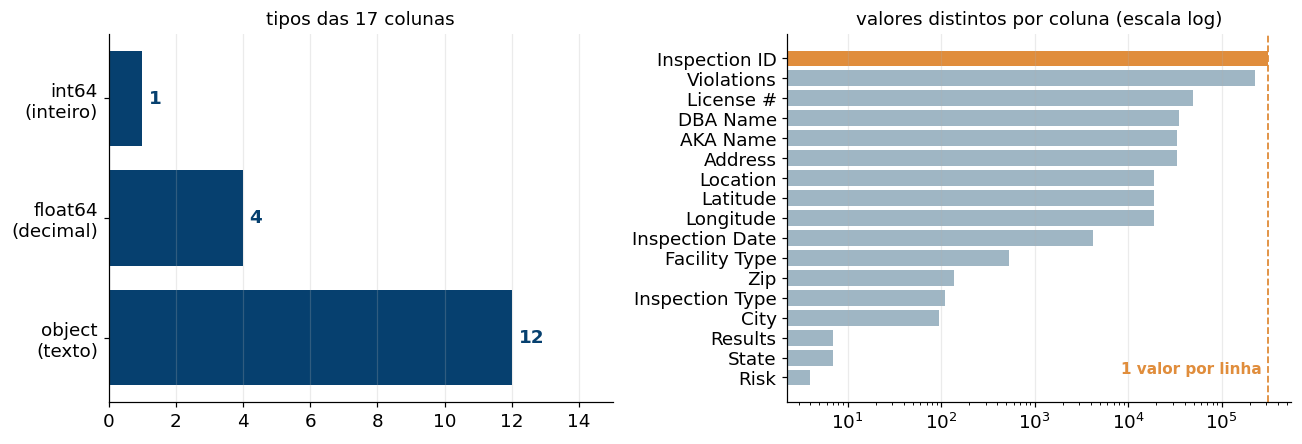

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

FIGS = Path("figuras"); FIGS.mkdir(exist_ok=True)
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 12, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

tipos = df.dtypes.value_counts()
nomes = {"str": "texto", "object": "texto", "int64": "inteiro", "float64": "decimal"}
ax1.barh([f"{t}\n({nomes.get(str(t), '')})" for t in tipos.index], tipos.values, color="#06406F")
for i, v in enumerate(tipos.values):
    ax1.text(v + .2, i, str(v), va="center", color="#06406F", fontweight="bold")
ax1.set_xlim(0, 15); ax1.set_title("tipos das 17 colunas"); ax1.grid(axis="y", alpha=0)

# escala log: de 4 (Risk) a 315.488 (Inspection ID) não cabe em escala linear
card = df.nunique().sort_values()
cores = ["#E08D3C" if n == "Inspection ID" else "#9FB6C4" for n in card.index]
ax2.barh(card.index, card.values, color=cores)
ax2.set_xscale("log")
ax2.axvline(len(df), color="#E08D3C", ls="--", lw=1.2)
ax2.text(len(df) * .85, .2, "1 valor por linha", color="#E08D3C",
         fontweight="bold", ha="right", fontsize=10)
ax2.set_title("valores distintos por coluna (escala log)"); ax2.grid(axis="y", alpha=0)

plt.tight_layout()
plt.savefig(FIGS / "fi-01-estrutura.png", dpi=200, bbox_inches="tight")   # ANTES do show()
plt.show()

---
## Conclusão da Estrutura

- **315.963 linhas × 17 colunas**; 12 de texto, 4 decimais, 1 inteira;
- A unidade da linha é a **inspeção**, e não o estabelecimento.

| achado | decisão |
|---|---|
| `Inspection ID` tem 1 valor por linha (iniciando de 44.247–2.643.194, com buracos) | descartar como preditor; manter como chave |
| `License #` = 49.093 estabelecimentos em 315.488 linhas; `0` usado como "sem licença" (831 linhas) | ler como texto; `0` vira ausente; **dividir treino/teste por licença ou por data**, nunca aleatório |
| `Location` é `Latitude`+`Longitude` em texto | descartar |
| `State` é `IL` em 315.864 de 315.963 linhas | descartar (quase constante) |
| `Zip` lido como `float64`; `Inspection Date` lida como texto | ler CEP como texto; converter a data (`%m/%d/%Y`) — cobre 04/01/2010 a 23/09/2026 |
| `City` tem 94 valores para uma cidade só (`Chicago`, `chicago`, `CCHICAGO`…) | normalizar antes de agrupar |
| `Risk` é ordinal (alto/médio/baixo) + 83 linhas `All` | codificar a ordem; tratar `All` à parte |
| `Facility Type` tem 527 valores, `Restaurant` = 68% | agrupar a cauda em `Outros` |
| `Results` tem 7 valores, dos quais 4 (≈44,7 mil linhas) são "inspeção não realizada" | definir o alvo explicitamente antes de modelar |

---
## 2 · Qualidade — *dá para confiar?*

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_q = df.copy(deep=True)

data_extracao = pd.Timestamp.today().normalize()

print(f"Linhas: {df_q.shape[0]:,}")
print(f"Colunas: {df_q.shape[1]}")
print(f"Data da análise: {data_extracao.date()}")

Linhas: 315,963
Colunas: 17
Data da análise: 2026-09-28


In [ ]:
resumo_vazios = pd.DataFrame({
    "faltantes": df_q.isna().sum(),
    "percentual_faltante": (df_q.isna().mean() * 100).round(2),
    "valores_distintos": df_q.nunique(dropna=True),
    "tipo_atual": df_q.dtypes.astype(str)
}).sort_values("faltantes", ascending=False)

colunas_com_vazio = resumo_vazios[
    resumo_vazios["faltantes"] > 0
]

display(colunas_com_vazio)

,faltantes,percentual_faltante,valores_distintos,tipo_atual
Violations,89080,28.19,225170,object
Facility Type,5347,1.69,527,object
AKA Name,2424,0.77,33450,object
Longitude,1051,0.33,18952,float64
Location,1051,0.33,18952,object
Latitude,1051,0.33,18952,float64
City,181,0.06,94,object
Risk,87,0.03,4,object
State,75,0.02,7,object
Zip,42,0.01,139,float64


In [ ]:
marcadores_de_vazio = {
    "",
    "nan",
    "null",
    "none",
    "n/a",
    "na",
    "unknown"
}

contagem_marcadores = {}

for coluna in df_q.select_dtypes(include="object").columns:
    valores = (
        df_q[coluna]
        .dropna()
        .astype(str)
        .str.strip()
        .str.lower()
    )

    contagem_marcadores[coluna] = int(
        valores.isin(marcadores_de_vazio).sum()
    )

marcadores_textuais = (
    pd.Series(
        contagem_marcadores,
        name="possiveis_vazios_escritos"
    )
    .sort_values(ascending=False)
)

display(
    marcadores_textuais[
        marcadores_textuais > 0
    ].to_frame()
)

,possiveis_vazios_escritos
DBA Name,3
Address,3


In [ ]:
duplicatas_exatas = int(df_q.duplicated().sum())

ids_repetidos = int(
    df_q["Inspection ID"]
    .duplicated(keep=False)
    .sum()
)

print("Linhas completamente idênticas:", duplicatas_exatas)
print("Linhas com Inspection ID repetido:", ids_repetidos)

Linhas completamente idênticas: 0
Linhas com Inspection ID repetido: 0


In [ ]:
licenca_valida = (
    df_q["License #"].notna()
    & df_q["License #"].ne(0)
)

chave_suspeita = [
    "License #",
    "Inspection Date",
    "Inspection Type"
]

mascara_suspeita = (
    licenca_valida
    & df_q.duplicated(chave_suspeita, keep=False)
)

possiveis_duplicatas = (
    df_q.loc[
        mascara_suspeita,
        [
            "Inspection ID",
            "License #",
            "DBA Name",
            "Inspection Date",
            "Inspection Type",
            "Results"
        ]
    ]
    .sort_values(chave_suspeita)
)

print(
    "Linhas com a mesma licença, data e tipo de inspeção:",
    len(possiveis_duplicatas)
)

display(possiveis_duplicatas.head(20))

Linhas com a mesma licença, data e tipo de inspeção: 2757


,Inspection ID,License #,DBA Name,Inspection Date,Inspection Type,Results
167333,1965749,241.0,HARD WATER BAR & GRILL,09/30/2016,Canvass,No Entry
168335,1965752,241.0,HOP HAUS ROGERS PARK,09/30/2016,Canvass,No Entry
229924,1092541,349.0,CLOVER CORP,08/09/2013,Canvass,Pass w/ Conditions
231233,1092549,349.0,KELLY'S PUB,08/09/2013,Canvass,Pass w/ Conditions
269630,543349,1362.0,MONTESSORI OF ENGLEWOOD,05/04/2011,Canvass,Pass
270090,166390,1362.0,JEWEL FOOD STORE #3232,05/04/2011,Canvass,Out of Business
34433,1965764,1392.0,JEWEL FOOD STORE #1296,09/30/2016,Complaint Re-Inspection,Fail
45356,1965672,1392.0,JEWEL FOOD STORE #1296,09/30/2016,Complaint Re-Inspection,Fail
126511,2129732,1491.0,BLACKIE'S,12/27/2017,Canvass,Out of Business
143013,2129733,1491.0,HALF SOUR,12/27/2017,Canvass,Pass w/ Conditions


In [ ]:
for coluna in ["Risk", "Results", "State"]:
    print(f"\n--- {coluna} ---")

    display(
        df_q[coluna]
        .value_counts(dropna=False)
        .rename("linhas")
        .to_frame()
    )


--- Risk ---


,linhas
Risk,
Risk 1 (High),235113
Risk 2 (Medium),56135
Risk 3 (Low),24545
NaN,87
All,83



--- Results ---


,linhas
Results,
Pass,163532
Fail,60842
Pass w/ Conditions,46875
Out of Business,25879
No Entry,14140
Not Ready,4599
Business Not Located,96



--- State ---


,linhas
State,
IL,315864
NaN,75
IN,13
CA,5
WI,3
DC,1
CO,1
NY,1


In [ ]:
cidade_normalizada = (
    df_q["City"]
    .astype("string")
    .str.strip()
    .str.upper()
)

print("Antes da normalização:")
display(
    df_q["City"]
    .value_counts(dropna=False)
    .head(15)
    .rename("linhas")
    .to_frame()
)

print("Depois de retirar espaços e padronizar maiúsculas:")
display(
    cidade_normalizada
    .value_counts(dropna=False)
    .head(15)
    .rename("linhas")
    .to_frame()
)

print(
    "Linhas com License # igual a zero:",
    int(df_q["License #"].eq(0).sum())
)

Antes da normalização:


,linhas
City,
CHICAGO,314653
Chicago,536
NaN,181
chicago,175
CCHICAGO,62
SCHAUMBURG,30
EVANSTON,28
CHicago,22
MAYWOOD,15


Depois de retirar espaços e padronizar maiúsculas:


,linhas
City,
CHICAGO,315386
<NA>,181
CCHICAGO,62
SCHAUMBURG,30
EVANSTON,28
MAYWOOD,16
ELK GROVE VILLAGE,13
CHICAGOCHICAGO,12
OAK PARK,12


Linhas com License # igual a zero: 833


In [ ]:
datas = pd.to_datetime(
    df_q["Inspection Date"],
    format="%m/%d/%Y",
    errors="coerce"
)

zip_numerico = pd.to_numeric(
    df_q["Zip"],
    errors="coerce"
)

latitude = pd.to_numeric(
    df_q["Latitude"],
    errors="coerce"
)

longitude = pd.to_numeric(
    df_q["Longitude"],
    errors="coerce"
)

datas_invalidas = int(datas.isna().sum())

datas_futuras = int(
    (datas > data_extracao).sum()
)

zips_fora_do_dominio = int(
    (
        zip_numerico.notna()
        & (
            (zip_numerico < 10000)
            | (zip_numerico > 99999)
        )
    ).sum()
)

zips_com_decimal = int(
    (
        zip_numerico.notna()
        & (zip_numerico % 1 != 0)
    ).sum()
)

coordenadas_fora_do_dominio = int(
    (
        latitude.notna()
        & ~latitude.between(-90, 90)
    ).sum()
    +
    (
        longitude.notna()
        & ~longitude.between(-180, 180)
    ).sum()
)

coordenadas_parciais = int(
    (latitude.isna() ^ longitude.isna()).sum()
)

print("Menor data válida:", datas.min())
print("Maior data válida:", datas.max())
print("Datas inválidas:", datas_invalidas)
print("Datas futuras:", datas_futuras)
print("CEPs fora do intervalo de 5 dígitos:", zips_fora_do_dominio)
print("CEPs com parte decimal diferente de zero:", zips_com_decimal)
print("Coordenadas fora do domínio:", coordenadas_fora_do_dominio)
print("Linhas com apenas uma coordenada presente:", coordenadas_parciais)

Menor data válida: 2010-01-04 00:00:00
Maior data válida: 2026-09-23 00:00:00
Datas inválidas: 0
Datas futuras: 0
CEPs fora do intervalo de 5 dígitos: 0
CEPs com parte decimal diferente de zero: 0
Coordenadas fora do domínio: 0
Linhas com apenas uma coordenada presente: 0


In [ ]:
colunas_geograficas = [
    "Latitude",
    "Longitude",
    "Location"
]

padrao_geografico = (
    df_q[colunas_geograficas]
    .isna()
    .value_counts(dropna=False)
    .rename("linhas")
    .reset_index()
)

display(padrao_geografico)

,Latitude,Longitude,Location,linhas
0,False,False,False,314912
1,True,True,True,1051


In [ ]:
violacoes_por_resultado = (
    df_q.groupby(
        "Results",
        dropna=False
    )
    .agg(
        linhas=("Inspection ID", "size"),
        violacoes_faltantes=(
            "Violations",
            lambda serie: serie.isna().sum()
        ),
        percentual_sem_violacoes=(
            "Violations",
            lambda serie: round(
                serie.isna().mean() * 100,
                2
            )
        )
    )
    .sort_values("linhas", ascending=False)
)

display(violacoes_por_resultado)

,linhas,violacoes_faltantes,percentual_sem_violacoes
Results,,,
Pass,163532,40671,24.87
Fail,60842,3648,6.00
Pass w/ Conditions,46875,948,2.02
Out of Business,25879,25835,99.83
No Entry,14140,13365,94.52
Not Ready,4599,4517,98.22
Business Not Located,96,96,100.00


In [ ]:
decisoes_qualidade = pd.DataFrame([
    {
        "problema": "License # igual a zero",
        "interpretacao": "Código usado para estabelecimento sem licença",
        "decisao_prevista": "Converter zero para ausente e tratar a coluna como identificador"
    },
    {
        "problema": "Grafias diferentes em City",
        "interpretacao": "Diferenças de maiúsculas e espaços",
        "decisao_prevista": "Remover espaços e converter o texto para maiúsculas"
    },
    {
        "problema": "Zip armazenado como decimal",
        "interpretacao": "CEP é código, não medida numérica",
        "decisao_prevista": "Validar e converter para texto"
    },
    {
        "problema": "Location repete latitude e longitude",
        "interpretacao": "Informação geográfica redundante",
        "decisao_prevista": "Manter latitude e longitude e descartar Location"
    },
    {
        "problema": "Risk com All ou ausente",
        "interpretacao": "Valores fora da escala Risk 1, Risk 2 e Risk 3",
        "decisao_prevista": "Investigar e tratar separadamente; não imputar automaticamente"
    },
    {
        "problema": "Results sem inspeção sanitária concluída",
        "interpretacao": "Out of Business, No Entry, Not Ready e Business Not Located não são aprovação ou falha",
        "decisao_prevista": "Excluir da definição do alvo após decisão do grupo"
    },
    {
        "problema": "Possíveis duplicatas",
        "interpretacao": "Repetição pode ser erro ou inspeção legítima",
        "decisao_prevista": "Remover somente duplicatas comprovadas"
    }
])

display(decisoes_qualidade)

,problema,interpretacao,decisao_prevista
0,License # igual a zero,Código usado para estabelecimento sem licença,Converter zero para ausente e tratar a coluna ...
1,Grafias diferentes em City,Diferenças de maiúsculas e espaços,Remover espaços e converter o texto para maiús...
2,Zip armazenado como decimal,"CEP é código, não medida numérica",Validar e converter para texto
3,Location repete latitude e longitude,Informação geográfica redundante,Manter latitude e longitude e descartar Location
4,Risk com All ou ausente,"Valores fora da escala Risk 1, Risk 2 e Risk 3",Investigar e tratar separadamente; não imputar...
5,Results sem inspeção sanitária concluída,"Out of Business, No Entry, Not Ready e Busines...",Excluir da definição do alvo após decisão do g...
6,Possíveis duplicatas,Repetição pode ser erro ou inspeção legítima,Remover somente duplicatas comprovadas


In [ ]:
print("CONCLUSÃO DA QUALIDADE")
print("-" * 50)

print(
    f"{len(colunas_com_vazio)} das {df_q.shape[1]} colunas "
    "possuem pelo menos um valor ausente."
)

print(
    f"Foram encontradas {duplicatas_exatas} linhas "
    "completamente idênticas."
)

print(
    f"Foram encontradas {ids_repetidos} linhas com "
    "Inspection ID repetido."
)

print(
    f"Existem {len(possiveis_duplicatas)} linhas com a mesma "
    "licença, data e tipo de inspeção; elas precisam ser "
    "investigadas antes de qualquer remoção."
)

print(
    f"Existem {datas_invalidas} datas que não puderam ser "
    "convertidas e {datas_futuras} datas futuras."
)

print(
    "\nAs principais necessidades previstas são: normalizar "
    "categorias de texto, converter CEP e licença para códigos, "
    "investigar os mecanismos dos valores ausentes e remover "
    "somente duplicatas comprovadas."
)

CONCLUSÃO DA QUALIDADE
--------------------------------------------------
12 das 17 colunas possuem pelo menos um valor ausente.
Foram encontradas 0 linhas completamente idênticas.
Foram encontradas 0 linhas com Inspection ID repetido.
Existem 2757 linhas com a mesma licença, data e tipo de inspeção; elas precisam ser investigadas antes de qualquer remoção.
Existem 0 datas que não puderam ser convertidas e {datas_futuras} datas futuras.

As principais necessidades previstas são: normalizar categorias de texto, converter CEP e licença para códigos, investigar os mecanismos dos valores ausentes e remover somente duplicatas comprovadas.


### Conclusão da qualidade

O dataset possui 315.963 inspeções e apresenta boa integridade estrutural: não foram encontradas linhas completamente duplicadas, `Inspection ID` repetidos, datas inválidas, datas futuras, CEPs impossíveis ou coordenadas fora do domínio.

Das 17 colunas, 12 apresentam algum valor ausente. A maior ausência está em `Violations`, com 89.080 linhas (28,19%). Essa ausência não ocorre ao acaso: ela está presente em quase todos os registros nos quais a inspeção não foi concluída, mas em apenas 6% dos resultados `Fail` e 2,02% dos resultados `Pass w/ Conditions`. Portanto, em muitos casos o vazio significa “não se aplica”, e não perda aleatória de informação.

`Facility Type` possui 5.347 ausências (1,69%) e deverá ser investigada antes de qualquer preenchimento. `AKA Name` pode estar ausente simplesmente porque o estabelecimento não possui nome alternativo. As 1.051 ausências de `Latitude`, `Longitude` e `Location` ocorrem exatamente nas mesmas linhas, indicando um único problema de geocodificação.

Foram encontradas 2.757 linhas com a mesma licença, data e tipo de inspeção. Como não existem linhas idênticas nem `Inspection ID` repetidos, esses casos não serão removidos automaticamente: podem representar inspeções legítimas ou estabelecimentos diferentes associados à mesma licença.

Também foram encontradas inconsistências categóricas. `City` possui diferenças de maiúsculas, espaços e erros de digitação; `Risk` contém 83 registros `All`, fora da escala de risco 1–3; e 24 registros apresentam estados diferentes de Illinois. Esses casos precisam ser normalizados ou investigados.

As decisões previstas são normalizar categorias textuais, converter `Zip` e `License #` para códigos, transformar licença zero em ausente, descartar `Location` por redundância, investigar as ausências de `Facility Type` e remover somente duplicatas comprovadas.

---
## 3 · Distribuições — *que forma tem cada variável?*

Objetivo : prever o fail. Entao vamos analisar o alvo : Results


In [ ]:
print(
    df["Results"]
    .value_counts(normalize=True, dropna=False)
    .round(3)
)

Results
Pass                    0.518
Fail                    0.193
Pass w/ Conditions      0.148
Out of Business         0.082
No Entry                0.045
Not Ready               0.015
Business Not Located    0.000
Name: proportion, dtype: float64


Analisa do numbro de inspecao pra estabelecimento.

In [ ]:
licencas_validas = df["License #"].replace(0, pd.NA)

insp_por_lic = licencas_validas.value_counts()

print(f"média   : {insp_por_lic.mean():.2f}")
print(f"mediana : {insp_por_lic.median():.0f}")
print(f"skew    : {insp_por_lic.skew():.2f}")

média   : 6.41
mediana : 3
skew    : 2.59


A média é 6.41, mais do dobro da médiana (3). O skew é de 2.59 : cauda à direita.
E melhor descever o estabelecimento tipico com a médiana (Media > Mediana + Skew alto -> uma minoridade de estebelecimentos tira a média por alto). A metade dos estabelecimentos é embaixo de 3. Utilizar a média nao representa a realidade.


In [ ]:
q1, q3 = insp_por_lic.quantile([.25, .75])
iqr = q3 - q1
sup = q3 + 1.5*iqr
print("limite supérieur :", sup)
print("suspects :", (insp_por_lic > sup).sum())

limite supérieur : 21.0
suspects : 2652


2652 établissements suspects sur ~49 100. Ils dépassent la limite, ils sont 5,4%
O limite Q3 + 1.5xIQR = 21 inspecoes, e 2652 estabelecimentos trespassam esse limite. Essa limita suposa uma distribucao ~ symetrica. Com skew alto, e normal que tem muitos suspetos.
Tem estabelecimentos inspecionados com muita frequencia (redes grandes o historico problematico por exemplo). Suspeito != Erro

Analyse de facility type

In [ ]:
vc = df["Facility Type"].value_counts()
print((vc.head(10).sum() / len(df)).round(2))
print((vc < 50).sum(), "types avec moins de 50 occurrences")

0.94
486 types avec moins de 50 occurrences


Os 10 tipos mais frequentes representem 94% dos tipos. 486/527 dos tipos aparecem menos de 50 vezes.
Decisao : possivelmente, regrupar os tipos que nao tem muitas representacoes em uma categoria "Outros", para permitir que tem um sinal estatico suficiente.

Canvass is the routine inspection.

In [ ]:
print(df["Inspection Type"].value_counts(normalize=True).head(10).round(3))

Inspection Type
Canvass                     0.516
License                     0.134
Canvass Re-Inspection       0.111
Complaint                   0.095
License Re-Inspection       0.041
Complaint Re-Inspection     0.040
Short Form Complaint        0.029
Non-Inspection              0.018
Suspected Food Poisoning    0.003
Consultation                0.002
Name: proportion, dtype: float64


Canvass represente 51% das linhas : e a inspecao de rotina que vamos analisar (vai o estabelecimento passar a proxima inspecao de rotina ?)

>
> | Achado | Decisao |
> |---|---|
> | `Results : 4 valores sem resultado sanitario` | Restringir a Pass/Fail/PassW/Conditions |
> | `Media` · `Mediana` | A media nao descreve bem : vamos utilisar a mediana |
> | `2636 suspetos` | Manter, sao casos legitimos |
> | `Facility Type` | Regrupas os tipos que nao sao representados bem |
> | `Inspection Type` | Ficar com canvass que represente o nosso objetivo |



---
## 4 · Correlação — *quais variáveis andam juntas?*

**Objetivo desta etapa:** descobrir quais variáveis andam junto com o **Fail** (sinal para o modelo) e quais andam juntas entre si (redundância, que vai guiar a seleção de features).

**Recorte usado** (decidido na seção 3): só inspeções **Canvass**, com `Results` em Pass, Pass w/ Conditions ou Fail. Alvo binário: `fail = 1` quando `Results == "Fail"`.

Cada tipo de par pede uma medida diferente:

| par | medida | por quê |
|---|---|---|
| numérica × numérica ou × alvo | Spearman | usa postos: aguenta assimetria e outliers (vimos skew alto na seção 3) |
| categórica × alvo | taxa de Fail por categoria (`groupby`, como na a03) | Pearson não faz sentido para categorias sem ordem |
| categórica × categórica | Cramér's V (0 a 1), como aprofundamento | resume a força da associação num número só |

In [ ]:
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from scipy.stats import chi2_contingency

base = df.copy()

base["License #"] = base["License #"].replace(0, pd.NA)

base["data"] = pd.to_datetime(
    base["Inspection Date"],
    format="%m/%d/%Y"
)

hist = (base.dropna(subset=["License #"]).sort_values(["License #", "data", "Inspection ID"]).copy())
hist["_fail"] = (hist["Results"] == "Fail").astype(int)
g = hist.groupby("License #")
hist["insp_anteriores"] = g.cumcount()
hist["fails_anteriores"] = g["_fail"].cumsum() - hist["_fail"]
hist["fail_anterior"] = g["_fail"].shift()
hist["dias_desde_ultima"] = g["data"].diff().dt.days

rotina = hist[hist["Inspection Type"].str.strip().str.upper().eq("CANVASS")
              & hist["Results"].isin(["Pass", "Pass w/ Conditions", "Fail"])]
hist["fail_ultima_rotina"] = rotina.groupby("License #")["_fail"].shift()
hist["taxa_fail_hist"] = hist["fails_anteriores"] / hist["insp_anteriores"].replace(0, np.nan)
cols_hist = ["insp_anteriores", "fails_anteriores", "fail_anterior", "dias_desde_ultima",
             "fail_ultima_rotina", "taxa_fail_hist"]
base[cols_hist] = hist[cols_hist]

ok = (base["Inspection Type"].str.strip().str.upper().eq("CANVASS")
      & base["Results"].isin(["Pass", "Pass w/ Conditions", "Fail"]))
d = base.loc[ok].copy()
d["fail"] = (d["Results"] == "Fail").astype(int)

d["risco"] = d["Risk"].map({"Risk 1 (High)": 1, "Risk 2 (Medium)": 2, "Risk 3 (Low)": 3})
d["risco_txt"] = d["Risk"].fillna("SEM RISCO")
d["ano"] = d["data"].dt.year
d["mes"] = d["data"].dt.month
d["dia_semana"] = d["data"].dt.dayofweek
d["n_violacoes"] = d["Violations"].str.count(r" \| ").add(1).fillna(0)
ft = d["Facility Type"].str.strip().str.upper().fillna("DESCONHECIDO")
d["tipo_estab"] = ft.where(ft.isin(ft.value_counts().head(10).index), "OUTROS")
d["zip"] = d["Zip"].map(lambda z: f"{z:.0f}" if pd.notna(z) else "SEM ZIP")

print(f"{len(d):,} inspeções Canvass com resultado sanitário")
print(f"taxa de Fail: {d['fail'].mean():.1%}")

132,088 inspeções Canvass com resultado sanitário
taxa de Fail: 22.6%


### 4.1 · Variáveis numéricas (Spearman)

`n_violacoes` entra só como **controle de vazamento**: o número de violações é anotado *durante* a inspeção, então ele praticamente descreve o próprio resultado. Se ele aparecer muito correlacionado com `fail`, isso confirma que a coluna `Violations` não pode ser usada como preditora da mesma inspeção.

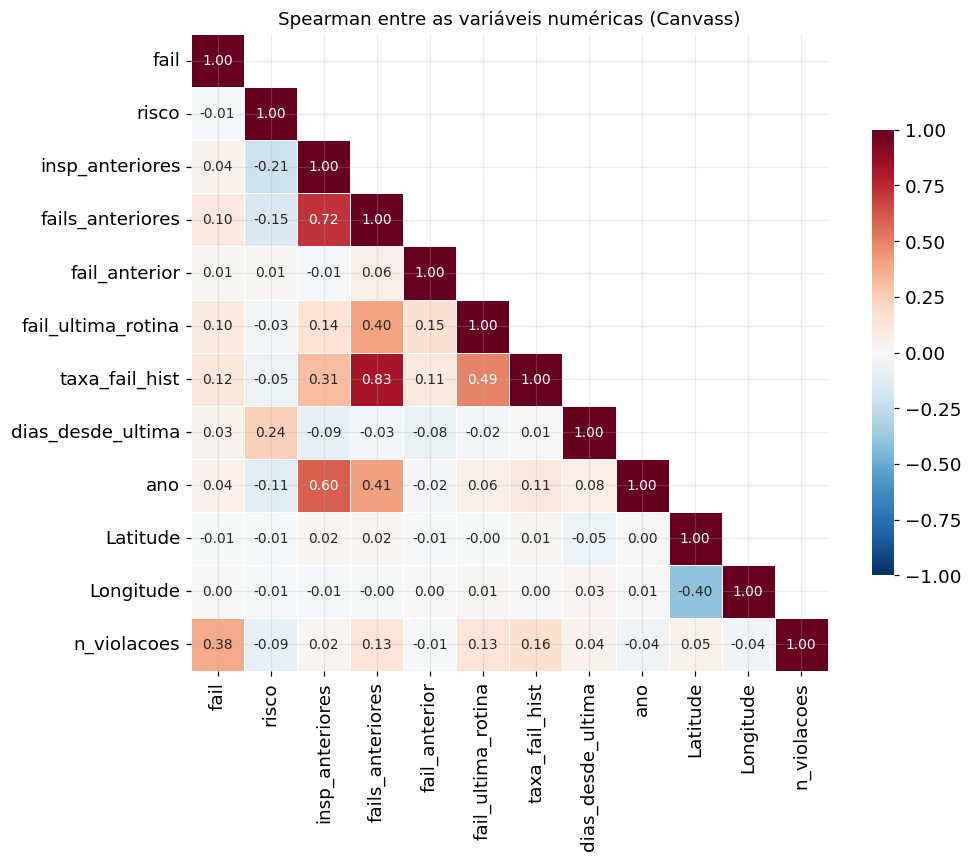

In [ ]:
num = ["fail", "risco", "insp_anteriores", "fails_anteriores", "fail_anterior",
       "fail_ultima_rotina", "taxa_fail_hist",
       "dias_desde_ultima", "ano", "Latitude", "Longitude", "n_violacoes"]
corr = d[num].corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            center=0, square=True, linewidths=.5, cbar_kws={"shrink": .7},
            annot_kws={"size": 9}, ax=ax)
ax.set_title("Spearman entre as variáveis numéricas (Canvass)")
plt.tight_layout()
plt.savefig(FIGS / "fi-04-spearman.png", dpi=200, bbox_inches="tight")
plt.show()

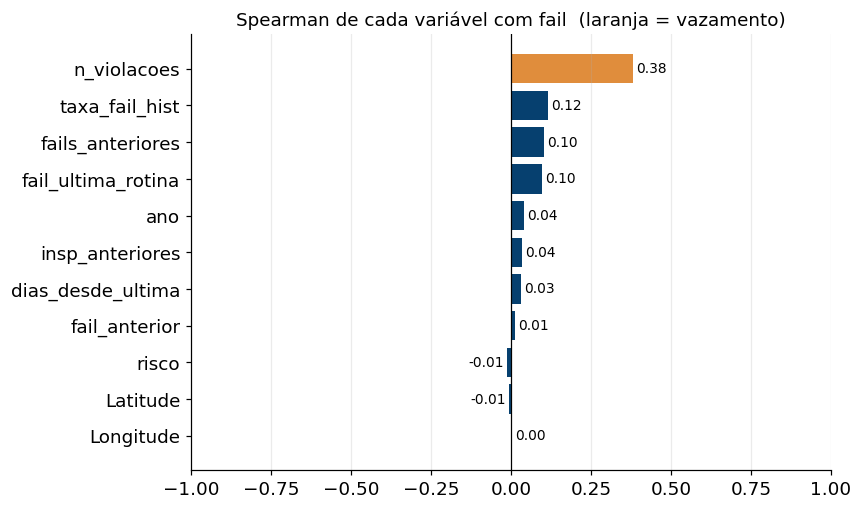

n_violacoes           0.380
taxa_fail_hist        0.116
fails_anteriores      0.104
fail_ultima_rotina    0.097
ano                   0.041
insp_anteriores       0.036
dias_desde_ultima     0.031
fail_anterior         0.013
risco                -0.011
Latitude             -0.007
Longitude             0.004
Name: fail, dtype: float64


In [ ]:
com_alvo = corr["fail"].drop("fail").sort_values(key=abs)
cores = ["#E08D3C" if c == "n_violacoes" else "#06406F" for c in com_alvo.index]

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(com_alvo.index, com_alvo.values, color=cores)
ax.axvline(0, color="black", lw=.8)
for i, v in enumerate(com_alvo.values):
    ax.text(v + (.01 if v >= 0 else -.01), i, f"{v:.2f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9)
ax.set_xlim(-1, 1)
ax.set_title("Spearman de cada variável com fail  (laranja = vazamento)")
ax.grid(axis="y", alpha=0)
plt.tight_layout()
plt.savefig(FIGS / "fi-04-spearman-alvo.png", dpi=200, bbox_inches="tight")
plt.show()

print(com_alvo.sort_values(key=abs, ascending=False).round(3))

### 4.2 · Variáveis categóricas: taxa de Fail por categoria

Para as categóricas, a pergunta é a mesma do `groupby` da a03: **a taxa de Fail muda de uma categoria para outra?** Se a taxa de um grupo fica longe da média geral (linha tracejada), a variável carrega sinal sobre o alvo.

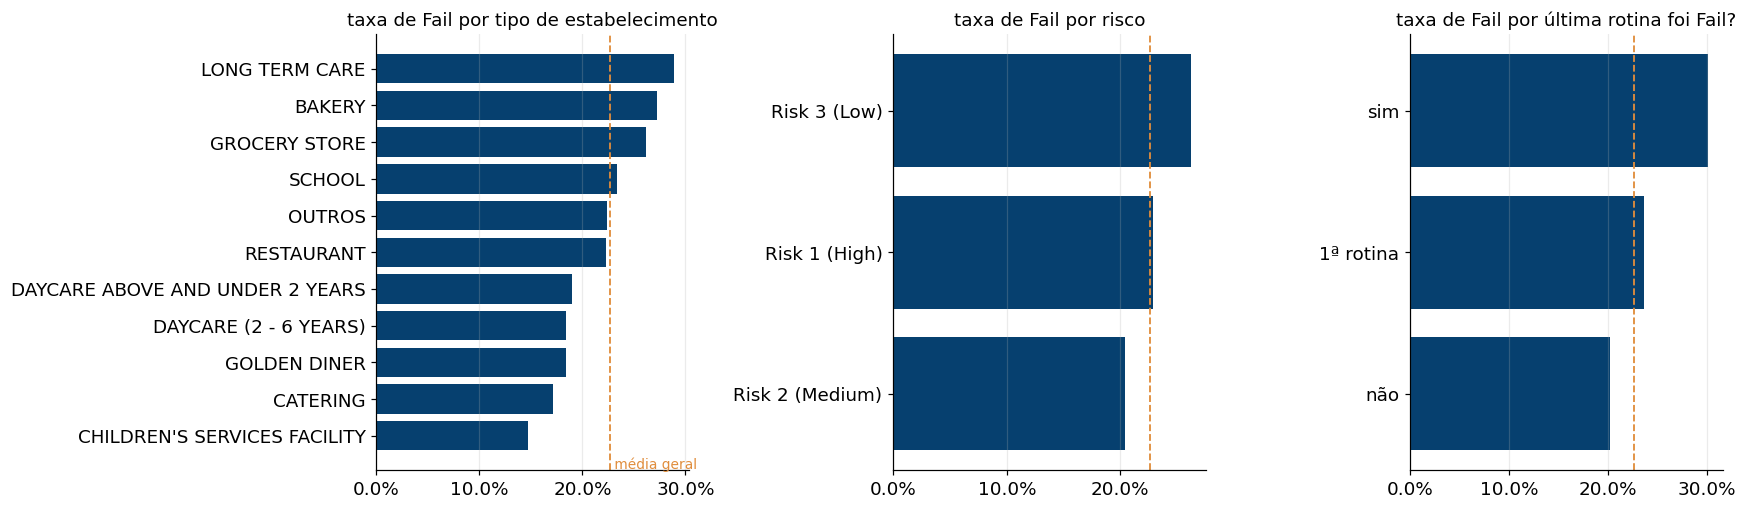


--- tipo de estabelecimento
                                  taxa      n
tipo_estab                                   
LONG TERM CARE                   0.289   1443
BAKERY                           0.273   2056
GROCERY STORE                    0.261  11663
SCHOOL                           0.233  14646
OUTROS                           0.224   4464
RESTAURANT                       0.223  91091
DAYCARE ABOVE AND UNDER 2 YEARS  0.190   1446
DAYCARE (2 - 6 YEARS)            0.184    990
GOLDEN DINER                     0.184    675
CATERING                         0.171    910
CHILDREN'S SERVICES FACILITY     0.147   2704

--- risco
                  taxa       n
risco_txt                     
SEM RISCO        1.000       1
Risk 3 (Low)     0.262    4282
Risk 1 (High)    0.229  108330
Risk 2 (Medium)  0.205   19475

--- última rotina foi Fail?
                     taxa      n
fail_ultima_rotina              
sim                 0.301  22589
1ª rotina           0.237  26871
não            

In [ ]:
# taxa de Fail por categoria: mostra PARA ONDE aponta a associação
taxa_geral = d["fail"].mean()
grupos = {
    "tipo de estabelecimento": d["tipo_estab"],
    "risco": d["risco_txt"],
    "última rotina foi Fail?": d["fail_ultima_rotina"].map({0: "não", 1: "sim"}).fillna("1ª rotina"),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (nome, s) in zip(axes, grupos.items()):
    t = d.groupby(s)["fail"].agg(taxa="mean", n="size")
    t = t[t["n"] >= 100].sort_values("taxa")          # categorias com pouco dado ficam de fora
    ax.barh(t.index, t["taxa"], color="#06406F")
    ax.axvline(taxa_geral, color="#E08D3C", ls="--", lw=1.2)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set_title(f"taxa de Fail por {nome}")
    ax.grid(axis="y", alpha=0)
axes[0].text(taxa_geral, -.9, " média geral", color="#E08D3C", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / "fi-04-taxa-fail-categorias.png", dpi=200, bbox_inches="tight")
plt.show()

for nome, s in grupos.items():
    print(f"\n--- {nome}")
    print(d.groupby(s)["fail"].agg(taxa="mean", n="size").sort_values("taxa", ascending=False).round(3))

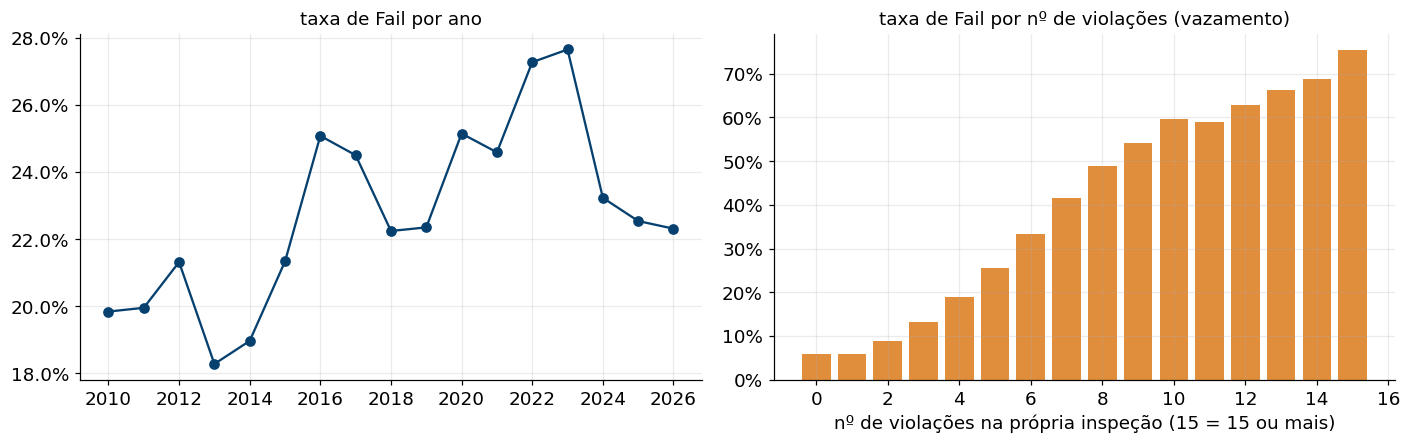

ano
2010    0.198
2011    0.200
2012    0.213
2013    0.183
2014    0.190
2015    0.213
2016    0.251
2017    0.245
2018    0.222
2019    0.224
2020    0.251
2021    0.246
2022    0.273
2023    0.277
2024    0.232
2025    0.225
2026    0.223
Name: fail, dtype: float64


In [ ]:
# tempo e vazamento: como a taxa de Fail muda com o ano e com o nº de violações
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

por_ano = d.groupby("ano")["fail"].mean()
ax1.plot(por_ano.index, por_ano.values, marker="o", color="#06406F")
ax1.yaxis.set_major_formatter(PercentFormatter(1))
ax1.set_title("taxa de Fail por ano")

por_viol = d.groupby(d["n_violacoes"].clip(upper=15))["fail"].mean()
ax2.bar(por_viol.index, por_viol.values, color="#E08D3C")
ax2.yaxis.set_major_formatter(PercentFormatter(1))
ax2.set_xlabel("nº de violações na própria inspeção (15 = 15 ou mais)")
ax2.set_title("taxa de Fail por nº de violações (vazamento)")

plt.tight_layout()
plt.savefig(FIGS / "fi-04-tempo-vazamento.png", dpi=200, bbox_inches="tight")
plt.show()

print(por_ano.round(3))

### 🔬 Aprofundamento: Cramér's V

Os gráficos acima mostram **para onde** aponta cada categoria. Para **comparar a força** da associação entre variáveis diferentes num número só, dá para usar o **Cramér's V** (0 = nenhuma associação, 1 = uma determina a outra). Não é conteúdo da aula: fica como complemento. Usamos a versão com correção de viés, porque colunas com muitas categorias (como `zip`) inflam o V sem correção.

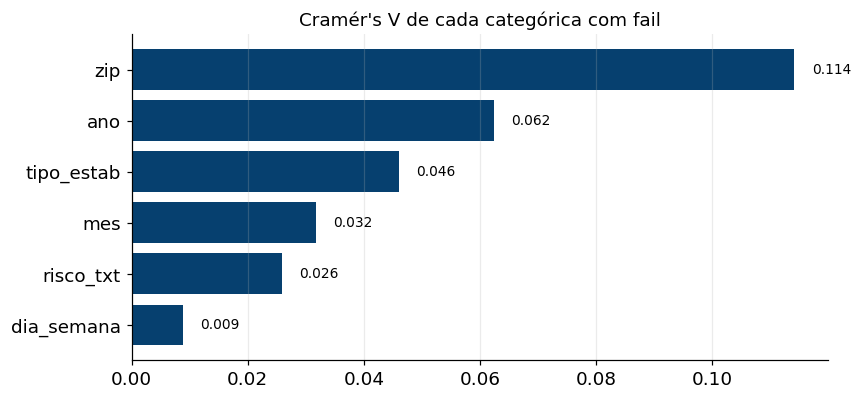

zip           0.114
ano           0.062
tipo_estab    0.046
mes           0.032
risco_txt     0.026
dia_semana    0.009
dtype: float64


In [ ]:
def cramers_v(x, y):
    """Cramér's V com correção de viés (Bergsma, 2013)."""
    tab = pd.crosstab(x, y)
    chi2 = chi2_contingency(tab, correction=False)[0]
    n = tab.values.sum()
    r, k = tab.shape
    phi2 = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    r_c, k_c = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2 / max(1e-12, min(k_c - 1, r_c - 1)))

cat = ["tipo_estab", "risco_txt", "zip", "ano", "mes", "dia_semana"]
v_alvo = pd.Series({c: cramers_v(d[c].astype(str), d["fail"]) for c in cat}).sort_values()

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(v_alvo.index, v_alvo.values, color="#06406F")
for i, v in enumerate(v_alvo.values):
    ax.text(v + .003, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_title("Cramér's V de cada categórica com fail")
ax.grid(axis="y", alpha=0)
plt.tight_layout()
plt.savefig(FIGS / "fi-04-cramer-alvo.png", dpi=200, bbox_inches="tight")
plt.show()

print(v_alvo.sort_values(ascending=False).round(3))

### 4.3 · Redundância entre as categóricas (aprofundamento, Cramér's V)

Se duas variáveis explicativas carregam a mesma informação, manter as duas não ajuda o modelo. Esta matriz é a base da **seleção de features**.

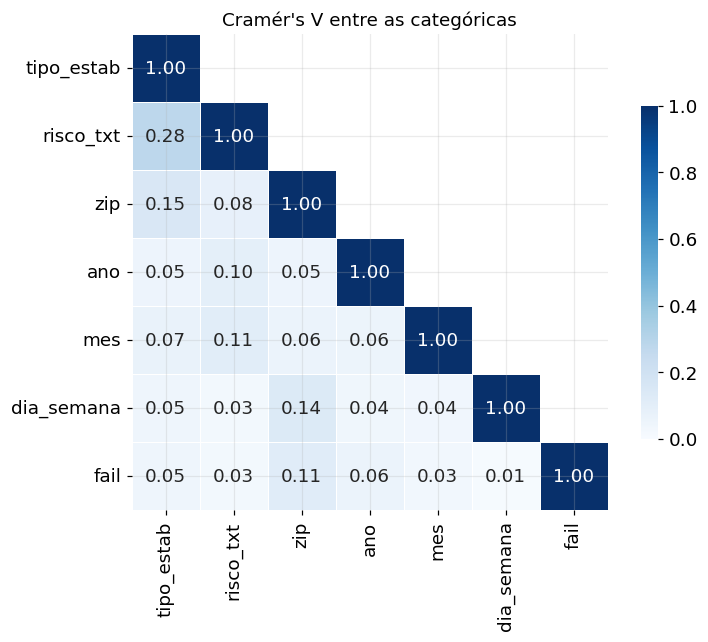

            tipo_estab  risco_txt   zip   ano   mes  dia_semana  fail
tipo_estab        1.00       0.28  0.15  0.05  0.07        0.05  0.05
risco_txt         0.28       1.00  0.08  0.10  0.11        0.03  0.03
zip               0.15       0.08  1.00  0.05  0.06        0.14  0.11
ano               0.05       0.10  0.05  1.00  0.06        0.04  0.06
mes               0.07       0.11  0.06  0.06  1.00        0.04  0.03
dia_semana        0.05       0.03  0.14  0.04  0.04        1.00  0.01
fail              0.05       0.03  0.11  0.06  0.03        0.01  1.00


In [ ]:
cols_v = cat + ["fail"]
mv = pd.DataFrame(np.eye(len(cols_v)), index=cols_v, columns=cols_v)
for i, a in enumerate(cols_v):
    for b in cols_v[i + 1:]:
        mv.loc[a, b] = mv.loc[b, a] = cramers_v(d[a].astype(str), d[b].astype(str))

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(mv, mask=np.triu(np.ones_like(mv, dtype=bool), k=1), annot=True, fmt=".2f",
            cmap="Blues", vmin=0, vmax=1, square=True, linewidths=.5,
            cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Cramér's V entre as categóricas")
plt.tight_layout()
plt.savefig(FIGS / "fi-04-cramer-matriz.png", dpi=200, bbox_inches="tight")
plt.show()

print(mv.round(2))

### Conclusão da Correlação

Base: **132.088 inspeções Canvass** com resultado sanitário, **22,6% de Fail** (cerca de 1 Fail para cada 3,4 aprovações).

📌 **Nenhuma variável sozinha explica o Fail.** Tirando o vazamento, a maior correlação com o alvo é |ρ| ≈ 0,12. O modelo vai depender de combinações de variáveis, e com o alvo desbalanceado a acurácia sozinha não serve como métrica.

📌 **Vazamento confirmado.** `n_violacoes` tem ρ = 0,38 com `fail`, mais de 3 vezes qualquer outra variável, e a taxa de Fail sobe com o número de violações. A coluna é preenchida durante a própria inspeção.

📌 **O histórico do estabelecimento é o melhor sinal.** `taxa_fail_hist` (0,116), `fails_anteriores` (0,104) e `fail_ultima_rotina` (0,097) lideram. Quando a última rotina foi Fail, a taxa sobe para **30,1%**, contra **20,3%** quando passou (1ª rotina: 23,7%).
Já `fail_anterior` (último registro de qualquer tipo) fica em ≈ 0,01: depois de um Fail vem uma re-inspeção, que em geral passa, e isso apaga o sinal. O que importa é a última **rotina**.

📌 **Redundâncias.** `insp_anteriores` × `fails_anteriores` = 0,72 e `insp_anteriores` × `ano` = 0,60: quanto mais tempo no dataset, mais inspeções acumuladas. `Risk` × `tipo_estab` tem V = 0,28.

📌 **Localização importa, mas não de forma linear.** `zip` é a categórica mais associada (V = 0,114), enquanto Latitude e Longitude têm ρ ≈ 0: o efeito existe por região, não "quanto mais ao norte, mais Fail".

📌 **O tempo muda o alvo.** A taxa de Fail vai de ~19% (2013–2014) a ~27–28% (2022–2023). Isso reforça a decisão da seção 1: dividir treino e teste **por data**.

📌 **Risk é contraintuitivo.** Risk 3 (Low) falha mais (26,2%) que High (22,9%) e Medium (20,5%). `Risk` descreve o tipo de operação e define a frequência de inspeção, não a chance de falhar numa inspeção.

| achado | decisão |
|---|---|
| `n_violacoes` / `Violations` ρ = 0,38 (vazamento) | **não usar** como preditora da mesma inspeção; no máximo, violações da rotina *anterior* |
| histórico: `taxa_fail_hist`, `fails_anteriores`, `fail_ultima_rotina` | **manter**: principais candidatas para a engenharia de features |
| `fail_anterior` ≈ 0,01 | **descartar**, substituída por `fail_ultima_rotina` |
| `insp_anteriores` redundante com `fails_anteriores` (0,72) e `ano` (0,60) | preferir `taxa_fail_hist` e avaliar tirar `insp_anteriores` na seleção |
| `zip` V = 0,114, lat/lon ρ ≈ 0 | usar `zip` (ou agrupamento geográfico); lat/lon cruas não ajudam um modelo linear |
| taxa de Fail muda com o `ano` | divisão treino/teste por data; `ano` pode entrar como feature |
| `tipo_estab` V = 0,046 (14,7% a 28,9%) | **manter** agrupado em top 10 + OUTROS |
| `Risk` fraco e parcialmente redundante com `tipo_estab` | manter por enquanto e decidir na seleção de features |
| `mes` V = 0,032, `dia_semana` V = 0,009 | sinal fraco; `dia_semana` é candidata a descarte |

---
## 5 · Preparação dos dados — como deixar a base pronta?

Nesta etapa, aplicamos as decisões tomadas durante a análise exploratória. Tratamos formatos, categorias, valores ausentes, duplicatas, recorte do problema e colunas com vazamento.

A preparação será feita em uma cópia do dataset congelado, preservando o `df` original.

In [ ]:
df_prep = df.copy(deep=True)

linhas_iniciais = len(df_prep)

print("Base original:", df.shape)
print("Base de preparação:", df_prep.shape)

Base original: (315963, 17)
Base de preparação: (315963, 17)


In [ ]:
marcadores_de_vazio = {
    "", "nan", "null", "none", "n/a", "na", "unknown"
}

colunas_texto = df_prep.select_dtypes(
    include=["object", "string"]
).columns

for coluna in colunas_texto:
    serie = df_prep[coluna].astype("string").str.strip()

    mascara_vazio = (
        serie
        .str.lower()
        .isin(marcadores_de_vazio)
    )

    serie = serie.mask(mascara_vazio, pd.NA)
    df_prep[coluna] = serie

colunas_categoricas = [
    "Inspection Type",
    "Results",
    "Risk",
    "Facility Type",
    "City",
    "State"
]

for coluna in colunas_categoricas:
    df_prep[coluna] = (
        df_prep[coluna]
        .str.upper()
        .str.replace(r"\s+", " ", regex=True)
    )

correcoes_city = {
    "CCHICAGO": "CHICAGO",
    "CHICAGOO": "CHICAGO",
    "CHICAGOCHICAGO": "CHICAGO"
}

df_prep["City"] = df_prep["City"].replace(correcoes_city)

In [ ]:
df_prep["Inspection Date"] = pd.to_datetime(
    df_prep["Inspection Date"],
    format="%m/%d/%Y",
    errors="coerce"
)

licenca_numerica = pd.to_numeric(
    df_prep["License #"],
    errors="coerce"
).astype("Int64")

df_prep["License #"] = (
    licenca_numerica
    .replace(0, pd.NA)
    .astype("string")
)

zip_numerico = pd.to_numeric(
    df_prep["Zip"],
    errors="coerce"
).astype("Int64")

df_prep["Zip"] = (
    zip_numerico
    .astype("string")
    .str.zfill(5)
)


print(df_prep[
    ["Inspection Date", "License #", "Zip"]
].dtypes)

Inspection Date    datetime64[ns]
License #          string[python]
Zip                string[python]
dtype: object


In [ ]:
duplicatas_exatas = int(
    df_prep.duplicated().sum()
)

ids_repetidos = int(
    df_prep["Inspection ID"]
    .duplicated(keep=False)
    .sum()
)

print("Duplicatas exatas:", duplicatas_exatas)
print("Linhas com Inspection ID repetido:", ids_repetidos)


df_prep = (
    df_prep
    .drop_duplicates()
    .copy()
)


if ids_repetidos > 0:
    display(
        df_prep[
            df_prep["Inspection ID"].duplicated(keep=False)
        ].sort_values("Inspection ID")
    )

Duplicatas exatas: 0
Linhas com Inspection ID repetido: 0


In [ ]:
resultados_validos = [
    "PASS",
    "PASS W/ CONDITIONS",
    "FAIL"
]

linhas_antes_recorte = len(df_prep)

mascara_recorte = (
    df_prep["Inspection Type"].eq("CANVASS")
    & df_prep["Results"].isin(resultados_validos)
)

df_prep = (
    df_prep
    .loc[mascara_recorte]
    .copy()
)


df_prep["fail"] = (
    df_prep["Results"].eq("FAIL")
    .astype("int8")
)

print("Linhas antes do recorte:", linhas_antes_recorte)
print("Linhas depois do recorte:", len(df_prep))
print("Linhas retiradas:", linhas_antes_recorte - len(df_prep))

display(
    df_prep["Results"]
    .value_counts()
    .to_frame("linhas")
)

print(
    "Taxa de Fail:",
    f"{df_prep['fail'].mean():.1%}"
)

Linhas antes do recorte: 315963
Linhas depois do recorte: 132088
Linhas retiradas: 183875


,linhas
Results,
PASS,75106
FAIL,29896
PASS W/ CONDITIONS,27086


Taxa de Fail: 22.6%


In [ ]:
categoricas_com_desconhecido = [
    "Facility Type",
    "Risk",
    "City",
    "State",
    "Zip"
]

for coluna in categoricas_com_desconhecido:
    df_prep[coluna] = (
        df_prep[coluna]
        .fillna("DESCONHECIDO")
    )


resumo_vazios_prep = pd.DataFrame({
    "faltantes": df_prep.isna().sum(),
    "percentual": (
        df_prep.isna().mean() * 100
    ).round(2)
})

display(
    resumo_vazios_prep[
        resumo_vazios_prep["faltantes"] > 0
    ].sort_values("faltantes", ascending=False)
)

,faltantes,percentual
Violations,8259,6.25
Latitude,557,0.42
Longitude,557,0.42
Location,557,0.42
License #,352,0.27
AKA Name,261,0.20
Address,1,0.00


In [ ]:
df_prep = df_prep.drop(
    columns=["Location"],
    errors="ignore"
)

colunas_com_vazamento = [
    "Results",
    "Violations"
]

colunas_de_identificacao = [
    "Inspection ID",
    "License #",
    "DBA Name",
    "AKA Name",
    "Address"
]

print("Colunas com vazamento:", colunas_com_vazamento)
print("Colunas de identificação:", colunas_de_identificacao)
print("Location removida:", "Location" not in df_prep.columns)

Colunas com vazamento: ['Results', 'Violations']
Colunas de identificação: ['Inspection ID', 'License #', 'DBA Name', 'AKA Name', 'Address']
Location removida: True


### Decisão sobre valores extremos

A análise exploratória não encontrou datas inválidas, CEPs impossíveis ou coordenadas fora dos limites geográficos.

Também foram encontrados estabelecimentos com quantidade elevada de inspeções. Esses casos não serão removidos, pois podem representar estabelecimentos antigos, redes ou locais fiscalizados com maior frequência.

Portanto, nenhum registro será excluído automaticamente como outlier. Caso alguma variável numérica precise de escala, essa transformação será aplicada posteriormente dentro do pipeline e ajustada somente com os dados de treino.

In [ ]:
decisoes_preparacao = pd.DataFrame([
    {
        "problema": "Textos com espaços e grafias diferentes",
        "decisao": "Remover espaços e padronizar categorias em maiúsculas"
    },
    {
        "problema": "City com erros evidentes de digitação",
        "decisao": "Corrigir apenas variações claramente referentes a Chicago"
    },
    {
        "problema": "License # igual a zero",
        "decisao": "Converter zero em valor ausente e tratar a coluna como código"
    },
    {
        "problema": "Zip armazenado como número decimal",
        "decisao": "Converter para código textual de cinco posições"
    },
    {
        "problema": "Resultados sem inspeção sanitária concluída",
        "decisao": "Manter somente Pass, Pass w/ Conditions e Fail"
    },
    {
        "problema": "Diferentes tipos de inspeção",
        "decisao": "Manter somente inspeções rotineiras Canvass"
    },
    {
        "problema": "Location repete latitude e longitude",
        "decisao": "Remover Location"
    },
    {
        "problema": "Results e Violations revelam o resultado atual",
        "decisao": "Não utilizar como preditoras da mesma inspeção"
    },
    {
        "problema": "Categorias ausentes",
        "decisao": "Representar como DESCONHECIDO"
    },
    {
        "problema": "Casos extremos legítimos",
        "decisao": "Manter; não remover outliers automaticamente"
    }
])

display(decisoes_preparacao)

,problema,decisao
0,Textos com espaços e grafias diferentes,Remover espaços e padronizar categorias em mai...
1,City com erros evidentes de digitação,Corrigir apenas variações claramente referente...
2,License # igual a zero,Converter zero em valor ausente e tratar a col...
3,Zip armazenado como número decimal,Converter para código textual de cinco posições
4,Resultados sem inspeção sanitária concluída,"Manter somente Pass, Pass w/ Conditions e Fail"
5,Diferentes tipos de inspeção,Manter somente inspeções rotineiras Canvass
6,Location repete latitude e longitude,Remover Location
7,Results e Violations revelam o resultado atual,Não utilizar como preditoras da mesma inspeção
8,Categorias ausentes,Representar como DESCONHECIDO
9,Casos extremos legítimos,Manter; não remover outliers automaticamente


In [ ]:
assert df_prep["Inspection Type"].eq("CANVASS").all()

assert df_prep["Results"].isin(
    resultados_validos
).all()

assert df_prep["fail"].isin([0, 1]).all()

assert df_prep["Inspection ID"].is_unique

assert "Location" not in df_prep.columns

assert not df_prep["License #"].eq("0").any()


print("PREPARAÇÃO CONCLUÍDA")
print("-" * 40)
print("Linhas originais:", linhas_iniciais)
print("Linhas preparadas:", len(df_prep))
print("Colunas preparadas:", df_prep.shape[1])
print("Inspection ID único:", df_prep["Inspection ID"].is_unique)
print("Taxa de Fail:", f"{df_prep['fail'].mean():.1%}")

PREPARAÇÃO CONCLUÍDA
----------------------------------------
Linhas originais: 315963
Linhas preparadas: 132088
Colunas preparadas: 17
Inspection ID único: True
Taxa de Fail: 22.6%


---
## 6 · Engenharia de features

Objetivo: medir se cada feature criada acrescenta informação nova ao modelo, e não só recombina o que ele já tinha. Seguimos os 5 passos do slide 26 da a09:

1. medir o ponto de partida com **todas** as colunas que já existem;
2. gerar candidatas (razão, diferença, agregação, extração, índice, interação, mudar a forma);
3. medir cada uma em validação cruzada, uma de cada vez;
4. classificar: recombinou, mudou a forma ou trouxe informação nova?
5. desconfiar do que sobe demais: comparar treino com validação.

**Métrica:** AUC, porque o alvo é binário (22,6% de Fail). É o papel que o R² faz na aula, que trabalha com regressão. **Modelo:** a mesma regressão logística do começo ao fim, como a aula faz com a regressão linear.

**Validação:** o slide 6 embaralha o dado antes de dividir em 5 partes. Aqui não embaralhamos: a seção 1 mostrou que o mesmo estabelecimento aparece várias vezes, e a seção 4 mostrou que a taxa de Fail muda com o ano. Por isso usamos `TimeSeriesSplit`: cada fold treina no passado e testa no futuro. Imputação, padronização e one-hot ficam dentro de um pipeline, ajustados só no treino de cada fold (antecipando a a11).

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# ponto de partida (slide 26, passo 1): TODAS as colunas que já existiam antes da engenharia
BASE_NUM = ["risco", "ano", "mes", "dia_semana", "Latitude", "Longitude"]
BASE_CAT = ["tipo_estab", "zip"]

# validação cruzada em ordem de data: cada fold treina no passado e testa no futuro (decisão da seção 1)
ordem = d.sort_values(["data", "Inspection ID"]).index
cv_t = TimeSeriesSplit(n_splits=5)

def medir(num_cols=(), cat_cols=(), base=True, treino=False):
    """AUC média em validação cruzada.
    base=True  -> soma as colunas passadas ao ponto de partida (BASE_NUM + BASE_CAT)
    base=False -> usa só as colunas passadas
    treino=True -> devolve também a AUC no próprio treino (slide 21)"""
    if base:
        num = BASE_NUM + [c for c in num_cols if c not in BASE_NUM]
        cat = BASE_CAT + [c for c in cat_cols if c not in BASE_CAT]
    else:
        num, cat = list(num_cols), list(cat_cols)
    etapas = []
    if num:
        etapas.append((make_pipeline(SimpleImputer(strategy="median", add_indicator=True),
                                     StandardScaler()), num))
    if cat:
        etapas.append((OneHotEncoder(handle_unknown="ignore", min_frequency=100), cat))
    modelo = make_pipeline(make_column_transformer(*etapas), LogisticRegression(max_iter=2000))
    r = cross_validate(modelo, d.loc[ordem, num + cat], d.loc[ordem, "fail"],
                       cv=cv_t, scoring="roc_auc", return_train_score=treino)
    if treino:
        return r["test_score"].mean(), r["train_score"].mean()
    return r["test_score"].mean()

In [ ]:
auc_0, treino_0 = medir(treino=True)
print(f"ponto de partida (todas as colunas originais): AUC = {auc_0:.3f} | treino = {treino_0:.3f}")
print(f"só risco e ano (base fraca da versão anterior)   : AUC = {medir(['risco', 'ano'], base=False):.3f}")

ponto de partida (todas as colunas originais): AUC = 0.554 | treino = 0.618
só risco e ano (base fraca da versão anterior)   : AUC = 0.501


O ponto de partida com todas as colunas originais tem **AUC = 0,554**. É o número que toda feature criada precisa superar (slide 26: no projeto, a feature criada tem de vencer as colunas que já estão lá). Com só `risco` e `ano`, a AUC seria 0,501, praticamente um sorteio.

A diferença entre treino (0,618) e validação (0,554) já existe no ponto de partida: 0,063. Esse número serve de referência para o passo 5.

### Candidatas de histórico

Na etapa de Correlação, um conjunto de colunas de histórico já tinha sido calculado (`insp_anteriores`, `fails_anteriores`, `fail_ultima_rotina`, `taxa_fail_hist`, `dias_desde_ultima`). Aqui cada uma é somada **sozinha** ao ponto de partida, para medir seu ganho real em validação cruzada, e não sua correlação isolada.

In [ ]:
# passo 3 do slide 26: cada candidata somada SOZINHA ao ponto de partida
candidatas = ["insp_anteriores", "fails_anteriores", "taxa_fail_hist",
              "dias_desde_ultima", "fail_ultima_rotina"]
linhas = []
for f in candidatas:
    cv, tr = medir([f], treino=True)
    linhas.append({"feature": f, "auc_cv": cv, "ganho": cv - auc_0, "auc_treino": tr})
tab_hist = pd.DataFrame(linhas).sort_values("ganho", ascending=False).reset_index(drop=True)
display(tab_hist.round(3))

,feature,auc_cv,ganho,auc_treino
0,taxa_fail_hist,0.576,0.022,0.629
1,fails_anteriores,0.576,0.022,0.628
2,fail_ultima_rotina,0.573,0.018,0.627
3,dias_desde_ultima,0.557,0.002,0.619
4,insp_anteriores,0.554,0.000,0.618


| Feature | Forma (slide 12) | Ganho | Interpretação |
|---|---|---|---|
| `taxa_fail_hist` | razão | +0,022 | proporção de Fails no histórico |
| `fails_anteriores` | agregação | +0,022 | empata com a razão: carrega a mesma informação |
| `fail_ultima_rotina` | extração | +0,018 | resultado da última rotina |
| `dias_desde_ultima` | diferença | +0,002 | quase nada |
| `insp_anteriores` | agregação | 0,000 | nenhum ganho |

`insp_anteriores` não rende nada. A seção 4 já apontava o motivo: ela anda junto com `ano` (ρ = 0,60), que já está no ponto de partida, porque estabelecimentos mais antigos no dataset acumulam mais inspeções. É o mesmo caso da `IdadeCasa` na aula (slide 10): a coluna parece nova, mas o modelo já tinha a informação.

Já `fail_ultima_rotina`, que tinha a 3ª maior correlação com o alvo na seção 4 (0,097), rende menos que `taxa_fail_hist` e `fails_anteriores`. Correlação mede a variável sozinha contra o alvo; o ganho mede o que ela acrescenta ao modelo (slide 22).

**Decisão:** `taxa_fail_hist` e `fails_anteriores` são as features prioritárias do histórico (como carregam a mesma informação, só uma deve ficar no modelo final); `fail_ultima_rotina` fica como candidata; `dias_desde_ultima` e `insp_anteriores` não se sustentam contra o ponto de partida.

### Corrigindo o vazamento

A etapa de Correlação confirmou que `n_violacoes` vaza o alvo: ρ = 0,38, porque a coluna é preenchida durante a mesma inspeção que se quer prever. Pela regra do slide 25 ("nenhuma feature pode ser construída com o alvo"), a coluna bruta não pode entrar no modelo.

Em vez de descartar essa informação por completo, criamos uma versão que não vaza: o número de violações da **rotina anterior** daquele estabelecimento (`viol_ultima_rotina`), obtido com o mesmo `.shift()` já usado para `fail_ultima_rotina`.

In [ ]:
hist["n_violacoes"] = hist["Violations"].str.count(r" \| ").add(1).fillna(0)

rotina2 = hist[hist["Inspection Type"].str.strip().str.upper().eq("CANVASS")
               & hist["Results"].isin(["Pass", "Pass w/ Conditions", "Fail"])]

hist["viol_ultima_rotina"] = rotina2.groupby("License #")["n_violacoes"].shift()
d["viol_ultima_rotina"] = hist["viol_ultima_rotina"]

auc_viol = medir(["viol_ultima_rotina"])
auc_viol_taxa = medir(["taxa_fail_hist", "viol_ultima_rotina"])
print(f"+ viol_ultima_rotina                  : {auc_viol:.3f} (ganho = {auc_viol - auc_0:+.3f})")
print(f"+ taxa_fail_hist + viol_ultima_rotina : {auc_viol_taxa:.3f} (ganho = {auc_viol_taxa - auc_0:+.3f})")

+ viol_ultima_rotina                  : 0.605 (ganho = +0.051)
+ taxa_fail_hist + viol_ultima_rotina : 0.611 (ganho = +0.057)


Sozinha, `viol_ultima_rotina` rende **+0,051**, mais que o dobro de qualquer outra feature de histórico. Junto com `taxa_fail_hist`, a AUC chega a **0,611** (+0,057).

**Decisão:** manter `viol_ultima_rotina`. É a prova de que um vazamento identificado pode ser reconstruído de forma honesta, usando só informação disponível no momento da previsão, e ainda ser a feature mais útil da seção.

### Índice composto: combinando os sinais de histórico


In [ ]:
d["gravidade_hist"] = (
    d["taxa_fail_hist"].fillna(0)
    + (d["fail_ultima_rotina"].fillna(0) * 0.5)
    + (d["viol_ultima_rotina"].fillna(0) / 10)
)

auc_idx6 = medir(["gravidade_hist"])
print(f"+ gravidade_hist (índice composto): {auc_idx6:.3f} (ganho = {auc_idx6 - auc_0:+.3f})")

+ gravidade_hist (índice composto): 0.589 (ganho = +0.035)


`gravidade_hist` junta três sinais de histórico numa coluna só, como o índice de amenidades da aula (slide 15). Sozinho, atinge **0,589** (+0,035): melhor que qualquer componente isolado, menos `viol_ultima_rotina` (+0,051).

A explicação está nos pesos (1; 0,5; 0,1), escolhidos à mão: a componente mais forte, `viol_ultima_rotina`, ficou com o menor peso. Combinar ajudou, mas a combinação escolhida não é a melhor possível.

**Decisão:** manter `gravidade_hist` como candidata e comparar, na seleção, o índice com os três componentes separados (deixando o modelo escolher os pesos).

### Interação risco × tipo de estabelecimento

O slide 16 define interação como o **produto** a × b: o efeito de uma variável depende do valor da outra, e o modelo linear não forma esse produto sozinho. Com duas categóricas, o produto das dummies de risco e de tipo é uma dummy para cada combinação (por exemplo, `Risk 1 (High) × RESTAURANT`).

A versão anterior desta célula usava a **taxa de Fail** de cada combinação, calculada na base inteira. Isso é Target Encoding medido no lugar errado, o vazamento que os slides 21 e 25 proíbem. Esta versão não usa o alvo.

In [ ]:
# interação = produto a × b (slide 16). Com duas categóricas, o produto das dummies de risco
# e de tipo é uma dummy para cada combinação risco × tipo. Nada aqui usa o alvo (slide 25).
d["risco_x_tipo"] = d["risco_txt"] + " × " + d["tipo_estab"]

auc_int = medir(cat_cols=["risco_x_tipo"])
print("combinações distintas:", d["risco_x_tipo"].nunique())
print(f"+ risco_x_tipo (produto): {auc_int:.3f} (ganho = {auc_int - auc_0:+.3f})")

combinações distintas: 28
+ risco_x_tipo (produto): 0.558 (ganho = +0.004)


São 28 combinações, e a interação rende **+0,004**: praticamente nada. As duas partes (`risco` e `tipo_estab`) já estavam no ponto de partida, e o slide 16 avisa que o produto de colunas que já estão no modelo não traz informação nova.

**Decisão:** descartar `risco_x_tipo`.

### Mudar a forma: log das contagens de histórico

O slide 14 mostra a outra família de transformação: mudar a **forma** da coluna, sem trazer nada de fora. Na seção 3, o número de inspeções por estabelecimento teve skew de 2,59 (cauda longa à direita). A regressão logística procura uma relação linear, e a cauda puxa essa relação para os poucos casos extremos. Testamos `log1p` em `insp_anteriores` e `dias_desde_ultima`, comparando cada versão com a coluna crua.

In [ ]:
# mudar a forma (slide 14): log1p reduz a cauda longa das contagens
for col in ["insp_anteriores", "dias_desde_ultima"]:
    print(f"{col:18s} skew: {d[col].skew():.2f} -> depois do log: {np.log1p(d[col]).skew():.2f}")

d["log_insp"] = np.log1p(d["insp_anteriores"])
d["log_dias"] = np.log1p(d["dias_desde_ultima"])

print()
for crua, log in [("insp_anteriores", "log_insp"), ("dias_desde_ultima", "log_dias")]:
    a_crua, a_log = medir([crua]), medir([log])
    print(f"{crua:18s}: {a_crua:.3f} | {log}: {a_log:.3f} (diferença = {a_log - a_crua:+.3f})")

insp_anteriores    skew: 4.33 -> depois do log: -0.30
dias_desde_ultima  skew: 4.12 -> depois do log: -2.77

insp_anteriores   : 0.554 | log_insp: 0.554 (diferença = -0.001)
dias_desde_ultima : 0.557 | log_dias: 0.558 (diferença = +0.001)


O log corrige a assimetria de `insp_anteriores` (skew de 4,33 para −0,30), mas inverte a de `dias_desde_ultima` (de 4,12 para −2,77: a cauda passa para a esquerda). Nas duas, o ganho em relação à coluna crua é nulo (−0,001 e +0,001).

Na aula, o log de `LotArea` subiu o R² de 0,323 para 0,400 (slide 14). Aqui não ajudou porque as duas colunas já não carregavam informação contra o ponto de partida: mudar a forma de uma coluna sem sinal não cria sinal.

**Decisão:** descartar `log_insp` e `log_dias`. Resultado negativo também é resultado (slide 26).

### Resumo: classificação e treino × CV

Passos 4 e 5 do slide 26. Para cada candidata: a forma de derivar (slide 12), a classificação (recombinou, mudou a forma ou trouxe informação nova) e a comparação entre a AUC de treino e a de validação. Uma feature que sobe o treino sem subir a validação é o sinal de alerta do slide 21.

,feature,forma (slide 12),classificação (slide 26),auc_cv,ganho,auc_treino,treino - cv
0,viol_ultima_rotina,extração,informação nova,0.605,0.051,0.644,0.039
1,gravidade_hist,índice composto,informação nova,0.589,0.035,0.633,0.044
2,taxa_fail_hist,razão,informação nova,0.576,0.022,0.629,0.053
3,fails_anteriores,agregação,informação nova,0.576,0.022,0.628,0.052
4,fail_ultima_rotina,extração,informação nova,0.573,0.018,0.627,0.054
5,risco_x_tipo,interação,recombinou o que já havia,0.558,0.004,0.621,0.063
6,log_dias,mudar a forma,mudou a forma,0.558,0.003,0.620,0.062
7,dias_desde_ultima,diferença,informação nova,0.557,0.002,0.619,0.063
8,insp_anteriores,agregação,informação nova,0.554,0.000,0.618,0.064
9,log_insp,mudar a forma,mudou a forma,0.554,-0.000,0.618,0.064


ponto de partida: CV 0.554 | treino 0.618 | treino - cv +0.063


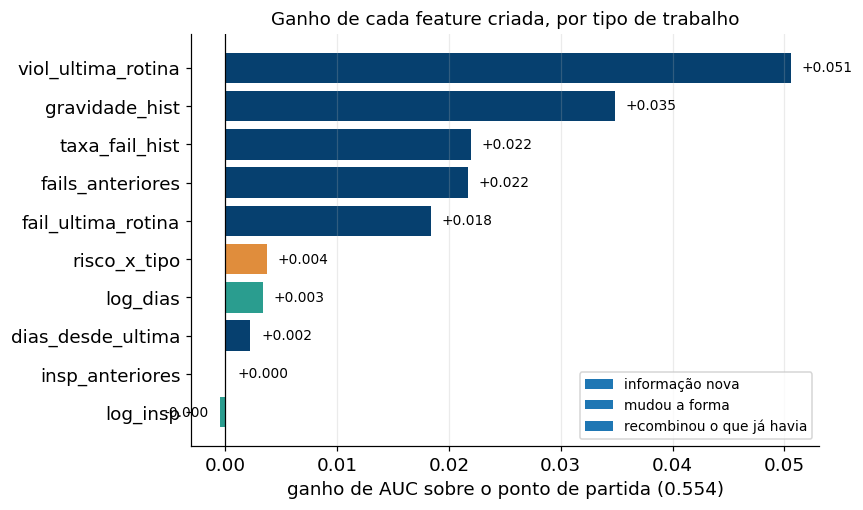

In [ ]:
# passos 4 e 5 do slide 26: classificar cada candidata e comparar treino × CV
classe = {
    "insp_anteriores":    ("agregação",       "informação nova"),
    "fails_anteriores":   ("agregação",       "informação nova"),
    "taxa_fail_hist":     ("razão",           "informação nova"),
    "dias_desde_ultima":  ("diferença",       "informação nova"),
    "fail_ultima_rotina": ("extração",        "informação nova"),
    "viol_ultima_rotina": ("extração",        "informação nova"),
    "gravidade_hist":     ("índice composto", "informação nova"),
    "log_insp":           ("mudar a forma",   "mudou a forma"),
    "log_dias":           ("mudar a forma",   "mudou a forma"),
    "risco_x_tipo":       ("interação",       "recombinou o que já havia"),
}

linhas = []
for f, (forma, tipo) in classe.items():
    num, cat = ([], [f]) if f == "risco_x_tipo" else ([f], [])
    cv, tr = medir(num, cat, treino=True)
    linhas.append({"feature": f, "forma (slide 12)": forma, "classificação (slide 26)": tipo,
                   "auc_cv": cv, "ganho": cv - auc_0, "auc_treino": tr, "treino - cv": tr - cv})
resumo = pd.DataFrame(linhas).sort_values("ganho", ascending=False).reset_index(drop=True)
display(resumo.round(3))
print(f"ponto de partida: CV {auc_0:.3f} | treino {treino_0:.3f} | treino - cv {treino_0 - auc_0:+.3f}")

cor_tipo = {"informação nova": "#06406F", "mudou a forma": "#2A9D8F",
            "recombinou o que já havia": "#E08D3C"}
s = resumo.sort_values("ganho")
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(s["feature"], s["ganho"], color=[cor_tipo[t] for t in s["classificação (slide 26)"]])
ax.axvline(0, color="black", lw=.8)
for i, v in enumerate(s["ganho"]):
    ax.text(v + (.001 if v >= 0 else -.001), i, f"{v:+.3f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9)
for t, c in cor_tipo.items():
    ax.barh([], [], color=c, label=t)
ax.legend(loc="lower right", fontsize=9)
ax.set_xlabel(f"ganho de AUC sobre o ponto de partida ({auc_0:.3f})")
ax.set_title("Ganho de cada feature criada, por tipo de trabalho")
ax.grid(axis="y", alpha=0)
plt.tight_layout()
plt.savefig(FIGS / "fi-06-features-auc.png", dpi=200, bbox_inches="tight")
plt.show()

### Conclusão da Engenharia de Features

| Feature | Forma (slide 12) | Classificação (slide 26) | Ganho em CV | Treino − CV | Decisão |
|---|---|---|---|---|---|
| `viol_ultima_rotina` | extração | informação nova | +0,051 | 0,039 | manter: melhor feature |
| `gravidade_hist` | índice composto | informação nova | +0,035 | 0,044 | candidata: comparar com os componentes na seleção |
| `taxa_fail_hist` | razão | informação nova | +0,022 | 0,053 | manter |
| `fails_anteriores` | agregação | informação nova | +0,022 | 0,052 | redundante com `taxa_fail_hist` |
| `fail_ultima_rotina` | extração | informação nova | +0,018 | 0,054 | candidata |
| `risco_x_tipo` | interação | recombinou o que já havia | +0,004 | 0,063 | descartar |
| `log_dias` | mudar a forma | mudou a forma | +0,003 | 0,062 | descartar |
| `dias_desde_ultima` | diferença | informação nova | +0,002 | 0,063 | descartar |
| `insp_anteriores` | agregação | informação nova (mas redundante com `ano`) | 0,000 | 0,064 | descartar |
| `log_insp` | mudar a forma | mudou a forma | 0,000 | 0,064 | descartar |

Ponto de partida: AUC 0,554, treino − CV = 0,063.

**Treino × CV (passo 5):** nenhuma feature aumentou de forma relevante a diferença entre treino e validação, e as de histórico até a diminuíram (0,039 com `viol_ultima_rotina`). O ganho delas aparece nos dados que o modelo não viu, e não é ajuste ao ruído do treino.

**Que tipo de trabalho pagou (slide 20):** trazer informação nova do histórico do estabelecimento rendeu de +0,018 a +0,051, e o índice composto +0,035. Recombinar o que já havia (interação) e mudar a forma (log) renderam praticamente zero. É o mesmo padrão da aula.

**Correlação não ordenou o ganho (slide 22):** `fail_ultima_rotina` tinha a 3ª maior correlação e ficou atrás de `taxa_fail_hist` e `fails_anteriores`.

O critério do G2 (pelo menos 3 features criadas e justificadas) está coberto: `viol_ultima_rotina`, `gravidade_hist`, `risco_x_tipo`, `log_insp` e `log_dias` foram criadas nesta seção, e as de histórico vieram da seção 4. Todas foram medidas em validação cruzada contra o mesmo ponto de partida.

## 7 · Seleção de features (aprofundamento)

> Não é conteúdo da a09: o slide 7 diz que cortar colunas é **seleção**, assunto da a20. Fica como complemento, assim como o Cramér's V na seção 4.

Objetivo: escolher, entre as colunas originais e as features criadas na seção 6, o menor conjunto que mantém o desempenho. A pergunta muda: na seção 6 cada feature foi somada **sozinha** ao ponto de partida; aqui medimos **o que cada uma acrescenta quando as outras já estão no modelo**. Usamos a mesma função `medir` da seção 6 (mesma métrica, mesmo modelo, mesma validação temporal), então os números das duas seções são comparáveis.

Primeiro, o teto: o que acontece se colocarmos **todas** as features criadas de uma vez?

In [ ]:
# teto: ponto de partida + TODAS as features criadas na seção 6
todas_criadas = ["insp_anteriores", "fails_anteriores", "taxa_fail_hist", "dias_desde_ultima",
                 "fail_ultima_rotina", "viol_ultima_rotina", "gravidade_hist", "log_insp", "log_dias"]
auc_tudo, treino_tudo = medir(todas_criadas, ["risco_x_tipo"], treino=True)

print(f"ponto de partida       : CV {auc_0:.3f} | treino {treino_0:.3f}")
print(f"+ todas as criadas     : CV {auc_tudo:.3f} | treino {treino_tudo:.3f}")

ponto de partida       : CV 0.554 | treino 0.618
+ todas as criadas     : CV 0.615 | treino 0.652


Com todas as features criadas, a AUC vai de 0,554 para **0,615**. Mas são 9 colunas numéricas a mais, além da interação com 28 combinações, e a seção 6 mostrou que várias delas não rendem nada sozinhas.

**Decisão:** usar 0,615 como teto de referência e procurar o menor conjunto que chegue perto dele.

### Índice composto ou componentes?

`gravidade_hist` é a soma de `taxa_fail_hist`, `fail_ultima_rotina` e `viol_ultima_rotina` com pesos escolhidos à mão (1; 0,5; 0,1). Colocar o índice **e** os componentes no mesmo modelo repetiria a mesma informação (é a multicolinearidade do slide 23), então testamos as duas versões separadamente, somadas ao ponto de partida.

In [ ]:
hist_comp = ["taxa_fail_hist", "fail_ultima_rotina", "viol_ultima_rotina"]

auc_idx  = medir(["gravidade_hist"])
auc_comp = medir(hist_comp)
hist_escolhido = hist_comp if auc_comp >= auc_idx else ["gravidade_hist"]

print(f"+ gravidade_hist (índice) : {auc_idx:.3f}")
print(f"+ os 3 componentes        : {auc_comp:.3f}")
print("-> histórico escolhido:", hist_escolhido)

+ gravidade_hist (índice) : 0.589
+ os 3 componentes        : 0.611
-> histórico escolhido: ['taxa_fail_hist', 'fail_ultima_rotina', 'viol_ultima_rotina']


Os três componentes separados chegam a **0,611**, contra **0,589** do índice. Com as colunas separadas, a regressão logística aprende os pesos a partir dos dados. Na seção 6, o índice deu o menor peso justamente à componente mais forte (`viol_ultima_rotina`).

**Decisão:** usar os três componentes e tirar `gravidade_hist`. O índice mostrou que combinar os sinais de histórico funciona, mas o modelo faz essa combinação melhor sozinho.

### Ablação: o que cada coluna acrescenta

Partimos do conjunto completo (as 8 colunas originais mais os 3 componentes de histórico, AUC 0,611) e tiramos uma coluna de cada vez. Se a AUC cai sem ela (Δ negativo), a coluna carrega informação que as outras não têm. Se fica igual ou sobe, ela é dispensável.

conjunto completo: 0.611


,feature,auc_sem_ela,delta
0,viol_ultima_rotina,0.5808,-0.0303
1,taxa_fail_hist,0.6063,-0.0048
2,tipo_estab,0.6096,-0.0014
3,ano,0.6102,-0.0009
4,dia_semana,0.6111,0.0000
5,risco,0.6111,0.0000
6,Latitude,0.6111,0.0001
7,Longitude,0.6111,0.0001
8,fail_ultima_rotina,0.6113,0.0002
9,mes,0.6117,0.0006


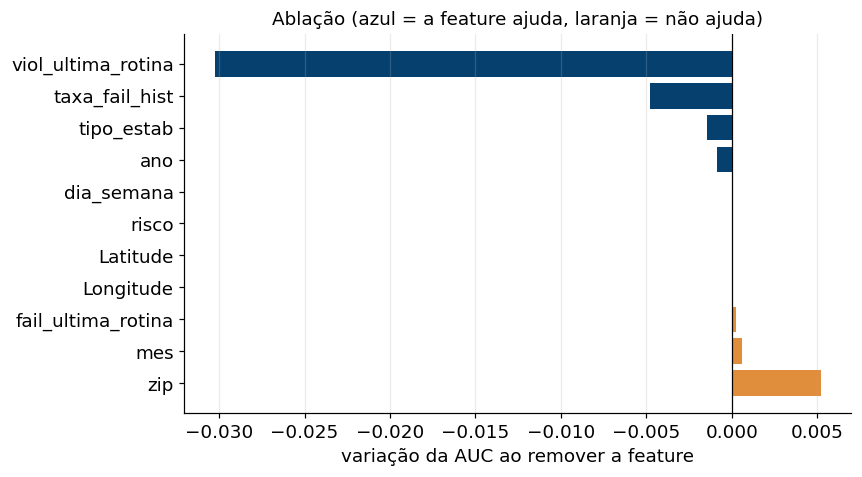

In [ ]:
# conjunto completo: colunas originais + histórico escolhido
num_sel  = BASE_NUM + hist_escolhido
cat_sel  = BASE_CAT
auc_full = medir(num_sel, cat_sel, base=False)
print(f"conjunto completo: {auc_full:.3f}")

linhas = []
for f in num_sel + cat_sel:
    auc = medir([c for c in num_sel if c != f], [c for c in cat_sel if c != f], base=False)
    linhas.append({"feature": f, "auc_sem_ela": auc, "delta": auc - auc_full})
ablacao = pd.DataFrame(linhas).sort_values("delta").reset_index(drop=True)
display(ablacao.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
cores = ["#06406F" if v < 0 else "#E08D3C" for v in ablacao["delta"]]
ax.barh(ablacao["feature"], ablacao["delta"], color=cores)
ax.axvline(0, color="black", lw=.8)
ax.invert_yaxis()
ax.set_xlabel("variação da AUC ao remover a feature")
ax.set_title("Ablação (azul = a feature ajuda, laranja = não ajuda)")
ax.grid(axis="y", alpha=0)
plt.tight_layout()
plt.savefig(FIGS / "fi-07-ablacao.png", dpi=200, bbox_inches="tight")
plt.show()

| Coluna | Δ ao remover | Leitura |
|---|---|---|
| `viol_ultima_rotina` | −0,030 | de longe a mais importante |
| `taxa_fail_hist` | −0,005 | segundo sinal de histórico |
| `tipo_estab` | −0,001 | pequeno, mas ajuda |
| `ano` | −0,0009 | perto de zero |
| `dia_semana`, `risco` | 0,000 | não acrescentam nada |
| `Latitude`, `Longitude` | +0,0001 | não acrescentam nada |
| `fail_ultima_rotina` | +0,0002 | não acrescenta nada |
| `mes` | +0,0006 | não acrescenta nada |
| `zip` | +0,005 | atrapalha |

Três leituras:

* `viol_ultima_rotina`, a versão sem vazamento de Violations criada na seção 6, é a coluna que mais pesa. Reconstruir o vazamento de forma honesta valeu a pena.
* `zip` era a categórica mais associada ao Fail na seção 4 (V = 0,114), mas na validação temporal **piora** o modelo. Com dezenas de CEPs em one-hot, o modelo aprende padrões por CEP do passado que não se repetem no futuro. É o slide 22 de novo: associação não garante ganho.
* `fail_ultima_rotina` não acrescenta nada com `taxa_fail_hist` no modelo. `risco` confirma a seção 4 (Risk descreve o tipo de operação, não a chance de falhar), e `Latitude`/`Longitude` confirmam o ρ ≈ 0 visto lá.

**Decisão:** manter as colunas com Δ claramente negativo e descartar `zip`, `mes`, `fail_ultima_rotina`, `Latitude`, `Longitude`, `risco` e `dia_semana`. `ano` fica para o corte final.

### As candidatas que ficaram de fora fazem falta?

Na seção 6, `fails_anteriores`, `insp_anteriores`, `dias_desde_ultima` e `risco_x_tipo` ficaram de fora. Aqui colocamos cada uma de volta no conjunto completo para confirmar.

In [ ]:
# as candidatas que ficaram de fora fazem falta no conjunto completo?
for extra, eh_cat in [("fails_anteriores", False), ("insp_anteriores", False),
                      ("dias_desde_ultima", False), ("risco_x_tipo", True)]:
    num = num_sel if eh_cat else num_sel + [extra]
    cat = cat_sel + [extra] if eh_cat else cat_sel
    auc = medir(num, cat, base=False)
    print(f"+ {extra:18s}: {auc:.3f} (Δ = {auc - auc_full:+.3f})")

+ fails_anteriores  : 0.613 (Δ = +0.002)
+ insp_anteriores   : 0.611 (Δ = -0.000)
+ dias_desde_ultima : 0.612 (Δ = +0.000)
+ risco_x_tipo      : 0.612 (Δ = +0.001)


Nenhuma faz diferença: `fails_anteriores` +0,002, `risco_x_tipo` +0,001, `insp_anteriores` e `dias_desde_ultima` 0,000. `fails_anteriores` é quase a mesma informação de `taxa_fail_hist` (na seção 6, as duas renderam +0,022).

**Decisão:** descartar as quatro. `taxa_fail_hist` já representa o histórico de Fails e, por ser uma proporção, não cresce só porque o estabelecimento está há mais tempo no dataset.

### Conjunto final

Regra de corte: fica a coluna cuja remoção derruba a AUC em mais de **0,001** (`LIMIAR`). É um critério simples e explícito: quem ficou abaixo dele não fez diferença mensurável no modelo.

numéricas  : ['taxa_fail_hist', 'viol_ultima_rotina']
categóricas: ['tipo_estab']
AUC final  : 0.616 | treino 0.612 (ponto de partida 0.554, ganho +0.061)


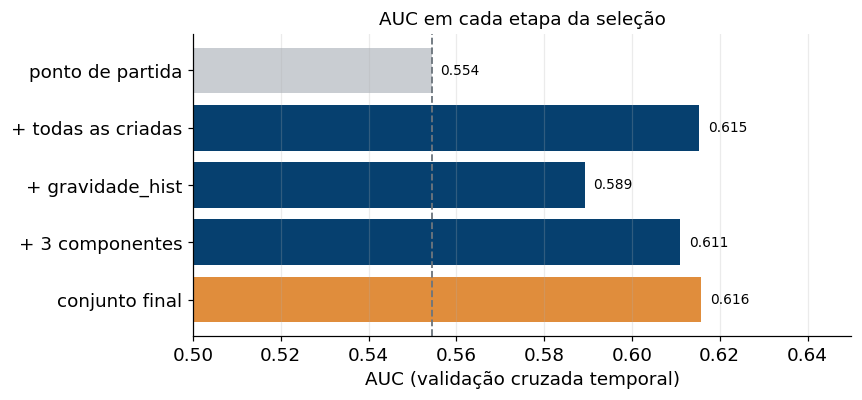

In [ ]:
LIMIAR = 0.001   # fica quem, ao sair, derruba a AUC mais que isso
ficam = ablacao.loc[ablacao["delta"] < -LIMIAR, "feature"].tolist()
num_final = [c for c in num_sel if c in ficam]
cat_final = [c for c in cat_sel if c in ficam]
auc_final, treino_final = medir(num_final, cat_final, base=False, treino=True)

print("numéricas  :", num_final)
print("categóricas:", cat_final)
print(f"AUC final  : {auc_final:.3f} | treino {treino_final:.3f} "
      f"(ponto de partida {auc_0:.3f}, ganho {auc_final - auc_0:+.3f})")

etapas_sel = {
    "ponto de partida": auc_0,
    "+ todas as criadas": auc_tudo,
    "+ gravidade_hist": auc_idx,
    "+ 3 componentes": auc_comp,
    "conjunto final": auc_final,
}
s = pd.Series(etapas_sel)
cores = ["#C9CDD2", "#06406F", "#06406F", "#06406F", "#E08D3C"]

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(s.index, s.values, color=cores)
ax.axvline(auc_0, color="#6C757D", ls="--", lw=1.2)
for i, v in enumerate(s.values):
    ax.text(v + .002, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0.50, 0.65)
ax.invert_yaxis()
ax.set_xlabel("AUC (validação cruzada temporal)")
ax.set_title("AUC em cada etapa da seleção")
ax.grid(axis="y", alpha=0)
plt.tight_layout()
plt.savefig(FIGS / "fi-07-selecao-auc.png", dpi=200, bbox_inches="tight")
plt.show()

### Conclusão da Seleção de Features

| Coluna | Δ ao remover | Decisão |
|---|---|---|
| `viol_ultima_rotina` | −0,030 | **manter** |
| `taxa_fail_hist` | −0,005 | **manter** |
| `tipo_estab` | −0,001 | **manter** |
| `ano` | −0,0009 | descartar (abaixo do limiar) |
| `dia_semana`, `risco` | 0,000 | descartar |
| `Latitude`, `Longitude` | +0,0001 | descartar |
| `fail_ultima_rotina` | +0,0002 | descartar (coberta por `taxa_fail_hist`) |
| `mes` | +0,0006 | descartar |
| `zip` | +0,005 | descartar (piora na validação temporal) |
| `gravidade_hist` | não se aplica | substituída pelos componentes (0,611 contra 0,589) |
| `fails_anteriores`, `insp_anteriores`, `dias_desde_ultima`, `risco_x_tipo` | de 0,000 a +0,002 | descartar |

**Conjunto final:** `taxa_fail_hist`, `viol_ultima_rotina` e `tipo_estab`, com AUC de **0,616**, contra 0,554 do ponto de partida (+0,061) e 0,615 com todas as features criadas. Com 3 colunas o modelo chega ao mesmo resultado que com todas. A AUC de treino (0,612) ficou no nível da validação, então não há sinal de ajuste ao ruído (slide 21).

Conclusão geral: quase todo o sinal para prever o Fail está no histórico do estabelecimento, principalmente em quantas violações ele teve na última rotina. Localização (`zip`, `Latitude`, `Longitude`), classificação de risco e calendário, que pareciam promissores na correlação, não se sustentam quando o modelo é testado no futuro. Isso reforça o que apareceu na seção 6: correlação isolada não garante ganho real no modelo.

Observação: com `LIMIAR = 0.001`, `tipo_estab` passa por pouco e `ano` fica logo abaixo.